In [1]:
# 데이터 처리
import pandas as pd
import numpy as np
import os
import pyarrow.parquet as pq
import re

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import seaborn as sns

from scipy.stats import f_oneway


# 윈도우 기본 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# EDA_자료준비

In [3]:
# 월별 파일명 리스트 생성
months = ['07', '08', '09', '10', '11', '12']
file_paths = [f'train/8.성과정보/2018{month}_train_성과정보.parquet' for month in months]

# 제외할 컬럼 리스트
exclude_columns = [   '혜택수혜율_R3M',    '혜택수혜율_B0M']

# 첫 파일로 전체 컬럼 목록 확인
all_columns = pq.read_schema(file_paths[0]).names
include_columns = [col for col in all_columns if col not in exclude_columns]

# 필요한 컬럼만 읽어서 병합
df_list = [pd.read_parquet(path, columns=include_columns) for path in file_paths]
df1 = pd.concat(df_list, ignore_index=True)

# 확인
print(df1.shape)
df1.head()

(2400000, 47)


,기준년월,ID,증감율_이용건수_신용_전월,증감율_이용건수_신판_전월,증감율_이용건수_일시불_전월,증감율_이용건수_할부_전월,증감율_이용건수_CA_전월,증감율_이용건수_체크_전월,증감율_이용건수_카드론_전월,증감율_이용금액_신용_전월,...,잔액_신판ca최대한도소진율_r3m,변동률_일시불평잔,변동률_RV일시불평잔,변동률_할부평잔,변동률_CA평잔,변동률_RVCA평잔,변동률_카드론평잔,변동률_잔액_B1M,변동률_잔액_일시불_B1M,변동률_잔액_CA_B1M
0,201807,TRAIN_000000,0.454548,0.454548,0.364727,1.999996,0.0,0.0,0.0,0.409766,...,0.885171,0.951930,0.999998,1.042805,0.999700,0.999998,0.999998,0.261886,0.270752,0.000000
1,201807,TRAIN_000001,-0.511808,-0.511808,-0.511808,0.000000,0.0,0.0,0.0,-1.010817,...,0.822757,1.290439,1.092698,0.905663,0.999998,0.999998,0.999998,-0.563388,-0.670348,0.000000
2,201807,TRAIN_000002,-0.062716,-0.062716,0.067843,-1.999996,0.0,0.0,0.0,-0.902166,...,0.863484,0.929196,1.006124,1.993590,0.852567,0.999998,0.999998,-0.046516,0.058114,-0.014191
3,201807,TRAIN_000003,0.135707,0.135707,0.153975,-1.999996,0.0,0.0,0.0,-0.866052,...,1.081369,1.020964,0.999998,1.050646,0.999877,0.999998,0.999998,0.023821,0.258943,0.000000
4,201807,TRAIN_000004,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000028,...,0.000000,0.000000,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.000000


In [4]:
# 대상 월 리스트
months = ['07', '08', '09', '10', '11', '12']

# 파일 경로 생성
file_paths = [f'train/1.회원정보/2018{month}_train_회원정보.parquet' for month in months]

# 필요한 컬럼만 추출하여 병합
df_list = []
for path in file_paths:
    df = pd.read_parquet(path)
    df_selected = df[['ID', 'Segment', '기준년월']]
    df_list.append(df_selected)

# 하나의 데이터프레임으로 합치기
member_df = pd.concat(df_list, ignore_index=True)

In [5]:
merged_df = df1.merge(member_df, on=['ID', '기준년월'], how='left')

In [6]:
merged_df

,기준년월,ID,증감율_이용건수_신용_전월,증감율_이용건수_신판_전월,증감율_이용건수_일시불_전월,증감율_이용건수_할부_전월,증감율_이용건수_CA_전월,증감율_이용건수_체크_전월,증감율_이용건수_카드론_전월,증감율_이용금액_신용_전월,...,변동률_일시불평잔,변동률_RV일시불평잔,변동률_할부평잔,변동률_CA평잔,변동률_RVCA평잔,변동률_카드론평잔,변동률_잔액_B1M,변동률_잔액_일시불_B1M,변동률_잔액_CA_B1M,Segment
0,201807,TRAIN_000000,0.454548,0.454548,0.364727,1.999996,0.0,0.000000,0.0,0.409766,...,0.951930,0.999998,1.042805,0.999700,0.999998,0.999998,0.261886,0.270752,0.000000,D
1,201807,TRAIN_000001,-0.511808,-0.511808,-0.511808,0.000000,0.0,0.000000,0.0,-1.010817,...,1.290439,1.092698,0.905663,0.999998,0.999998,0.999998,-0.563388,-0.670348,0.000000,E
2,201807,TRAIN_000002,-0.062716,-0.062716,0.067843,-1.999996,0.0,0.000000,0.0,-0.902166,...,0.929196,1.006124,1.993590,0.852567,0.999998,0.999998,-0.046516,0.058114,-0.014191,C
3,201807,TRAIN_000003,0.135707,0.135707,0.153975,-1.999996,0.0,0.000000,0.0,-0.866052,...,1.020964,0.999998,1.050646,0.999877,0.999998,0.999998,0.023821,0.258943,0.000000,D
4,201807,TRAIN_000004,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000028,...,0.000000,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.000000,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,0.000000,0.000000,0.000000,0.000000,0.0,-0.081943,0.0,0.000027,...,0.999998,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.000000,E
2399996,201812,TRAIN_399996,0.073804,0.073804,0.073804,0.000000,0.0,0.000000,0.0,0.207099,...,0.615087,0.999998,0.999998,0.999998,0.999998,0.921733,-0.203251,-0.159143,0.000000,D
2399997,201812,TRAIN_399997,-0.040432,-0.040432,-0.040432,0.000000,0.0,0.000000,0.0,0.254495,...,1.036370,0.999998,0.345027,0.999998,0.999998,0.999998,0.027319,0.126581,0.000000,C
2399998,201812,TRAIN_399998,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000034,...,0.999998,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.000000,E


In [7]:
# 전월 기준 이용건수 증감률
usage_count_mom_cols = [
    '증감율_이용건수_신용_전월', '증감율_이용건수_신판_전월', '증감율_이용건수_일시불_전월',
    '증감율_이용건수_할부_전월', '증감율_이용건수_CA_전월', '증감율_이용건수_체크_전월',
    '증감율_이용건수_카드론_전월'
]  # 💡 전월 대비 이용건수 증감율

# 전월 기준 이용금액 증감률
usage_amount_mom_cols = [
    '증감율_이용금액_신용_전월', '증감율_이용금액_신판_전월', '증감율_이용금액_일시불_전월',
    '증감율_이용금액_할부_전월', '증감율_이용금액_CA_전월', '증감율_이용금액_체크_전월',
    '증감율_이용금액_카드론_전월'
]  # 💡 전월 대비 이용금액 증감율

# 분기 기준 이용건수 증감률
usage_count_qoq_cols = [
    '증감율_이용건수_신용_분기', '증감율_이용건수_신판_분기', '증감율_이용건수_일시불_분기',
    '증감율_이용건수_할부_분기', '증감율_이용건수_CA_분기', '증감율_이용건수_체크_분기',
    '증감율_이용건수_카드론_분기'
]  # 📊 분기 대비 이용건수 증감율

# 분기 기준 이용금액 증감률
usage_amount_qoq_cols = [
    '증감율_이용금액_신용_분기', '증감율_이용금액_신판_분기', '증감율_이용금액_일시불_분기',
    '증감율_이용금액_할부_분기', '증감율_이용금액_CA_분기', '증감율_이용금액_체크_분기',
    '증감율_이용금액_카드론_분기'
]  # 📊 분기 대비 이용금액 증감율

# 최근 6/3개월 신판 한도 소진율
limit_usage_credit_cols = [
    '잔액_신판평균한도소진율_r6m', '잔액_신판최대한도소진율_r6m',
    '잔액_신판평균한도소진율_r3m', '잔액_신판최대한도소진율_r3m'
]  # 💳 신판 한도 소진율 (3/6개월 평균, 최대)

# 신판+CA(현금서비스) 포함 소진율
limit_usage_credit_ca_cols = [
    '잔액_신판ca평균한도소진율_r6m', '잔액_신판ca최대한도소진율_r6m',
    '잔액_신판ca평균한도소진율_r3m', '잔액_신판ca최대한도소진율_r3m'
]  # 💳💸 신판+현금서비스 한도 소진율

balance_change_cols = [
    '변동률_일시불평잔', '변동률_RV일시불평잔', '변동률_할부평잔',
    '변동률_CA평잔', '변동률_RVCA평잔', '변동률_카드론평잔',
    '변동률_잔액_B1M', '변동률_잔액_일시불_B1M', '변동률_잔액_CA_B1M'
]  # 💰 평잔 및 잔액 변동률 (일시불/할부/CA/카드론 등)


# EDA

## usage_count_mom_cols

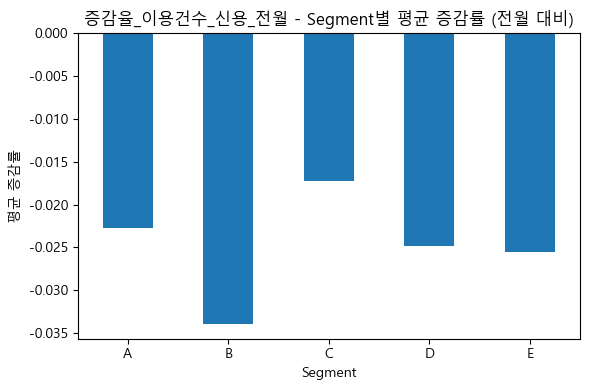

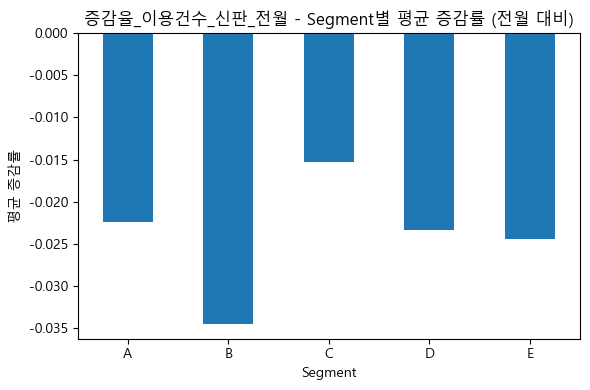

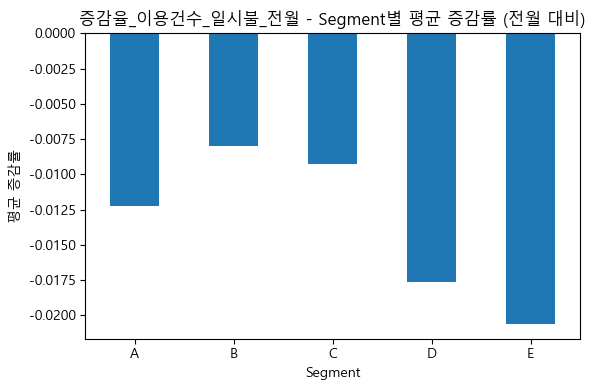

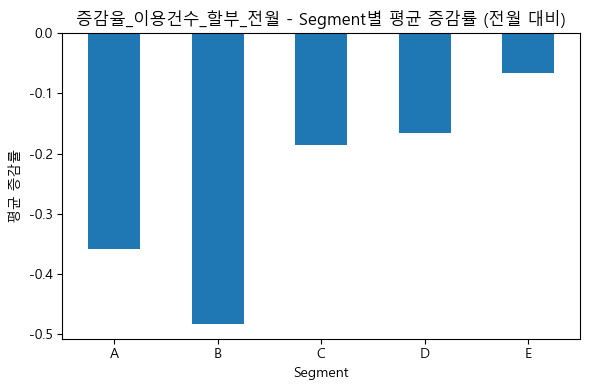

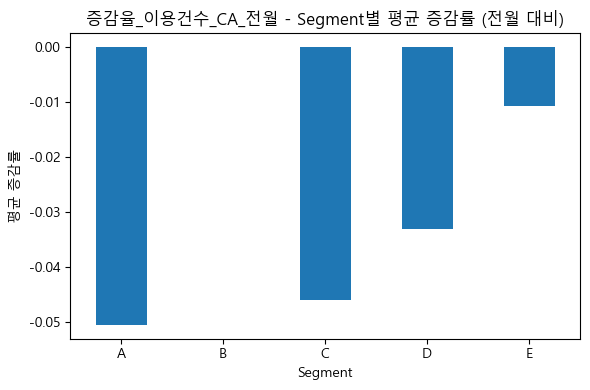

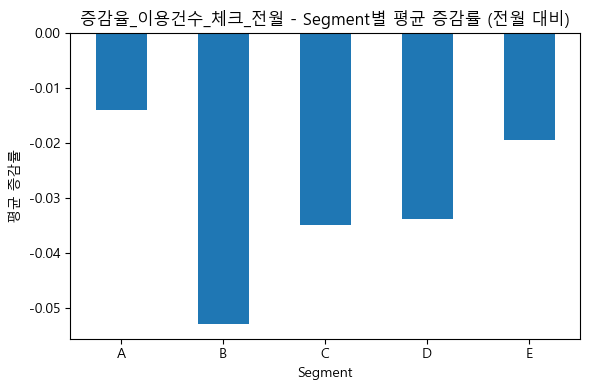

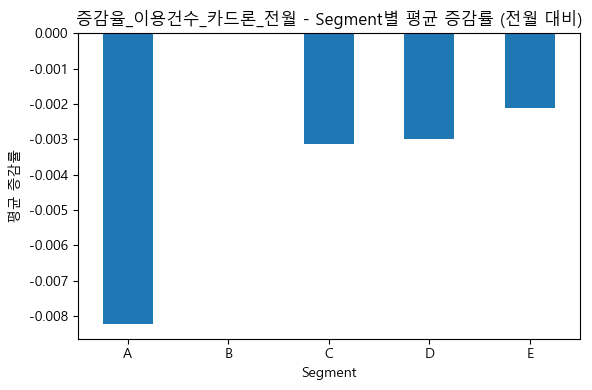

In [10]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[usage_count_mom_cols].mean()

# 컬럼별로 막대그래프 시각화
for col in usage_count_mom_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].plot(kind='bar')
    plt.title(f'{col} - Segment별 평균 증감률 (전월 대비)')
    plt.xlabel('Segment')
    plt.ylabel('평균 증감률')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

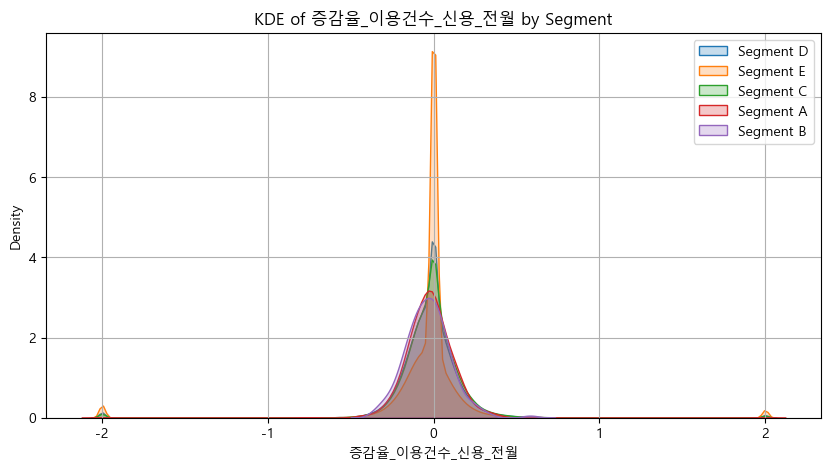

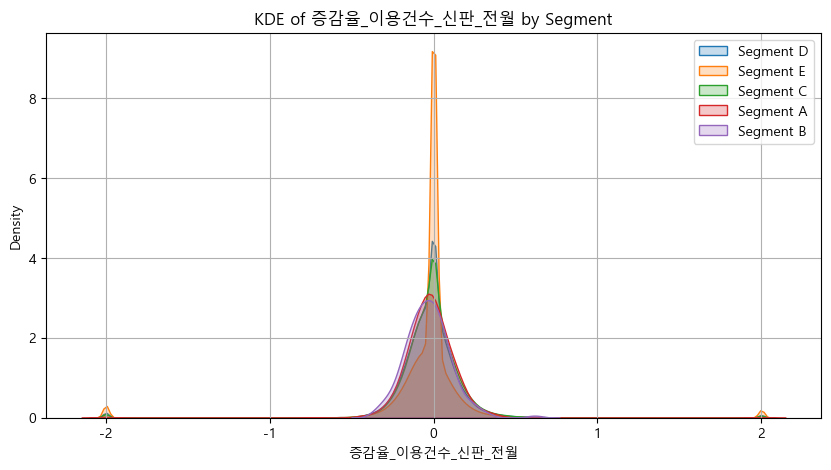

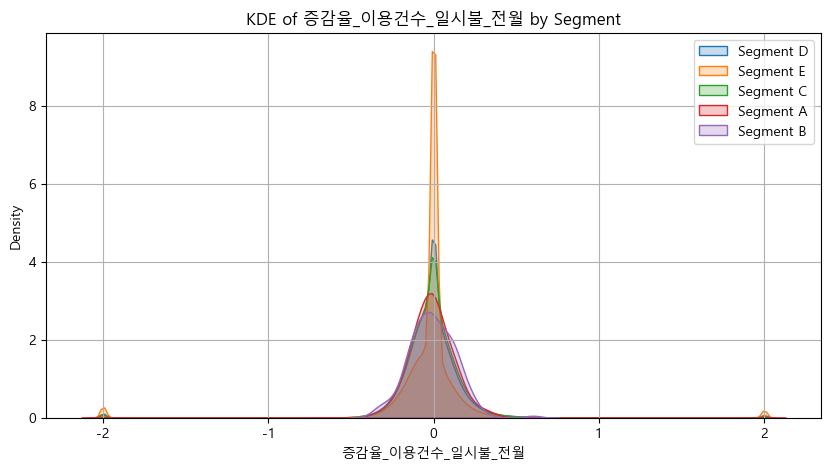

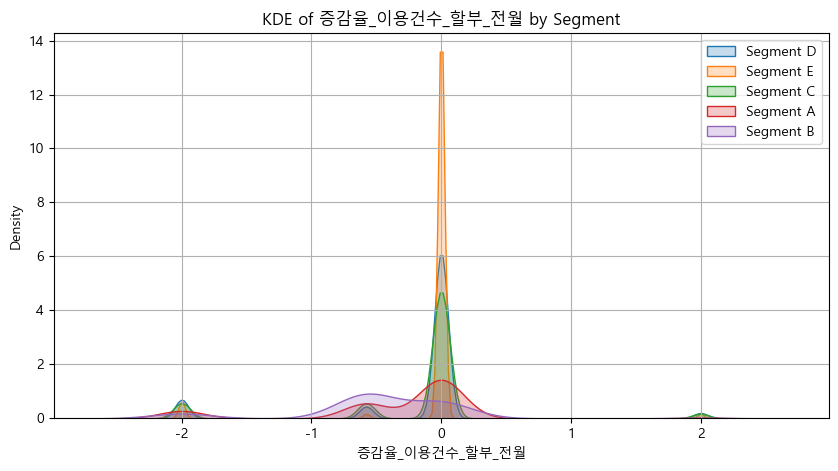

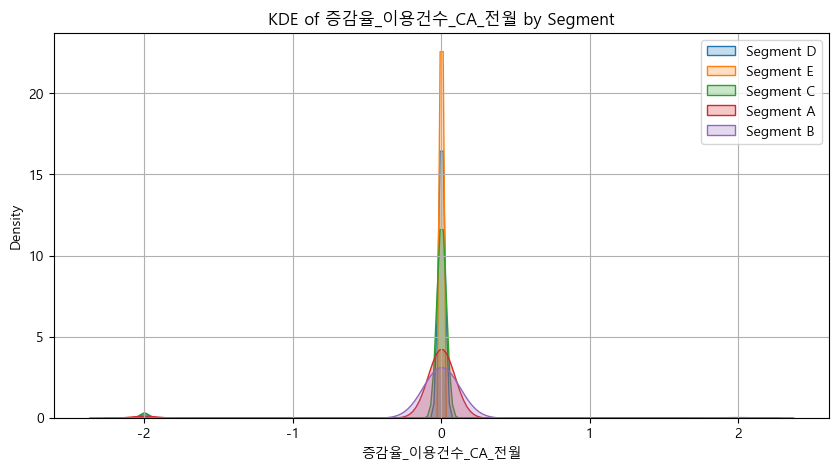

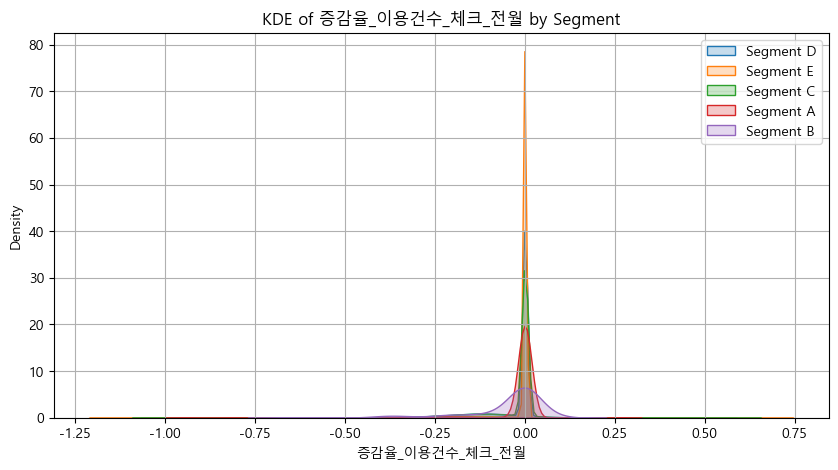

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\1687606326.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


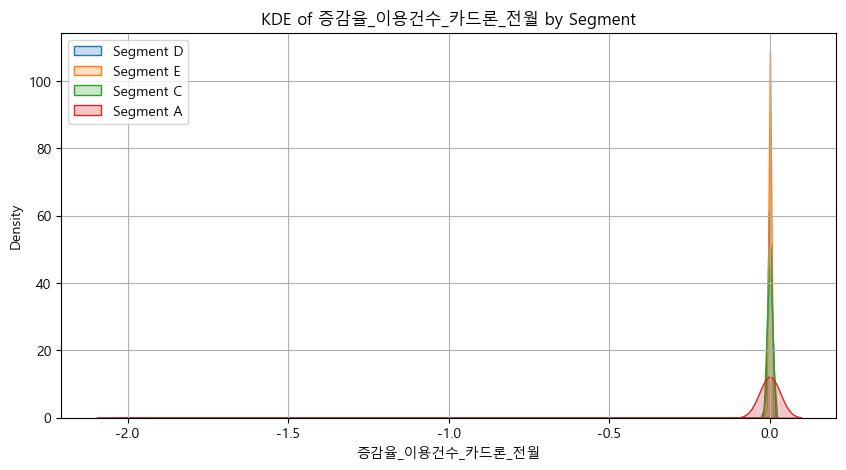

In [11]:
for col in usage_count_mom_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## usage_amount_mom_cols

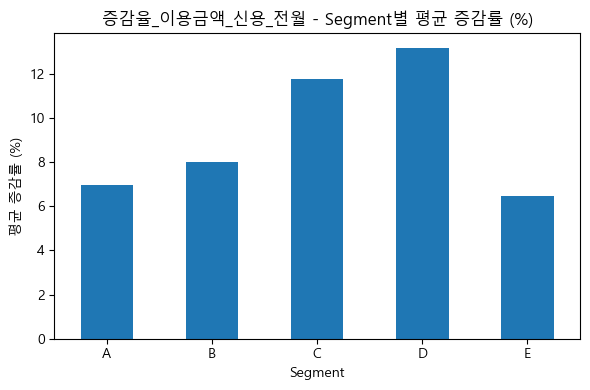

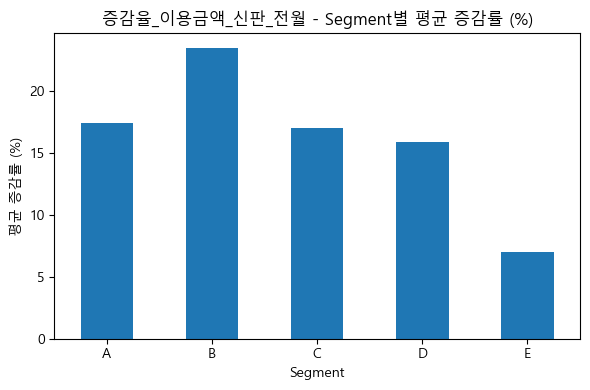

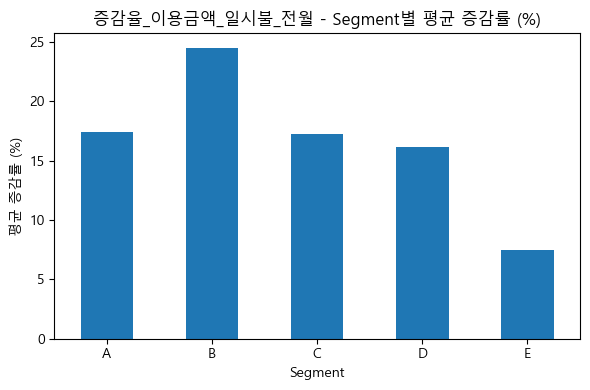

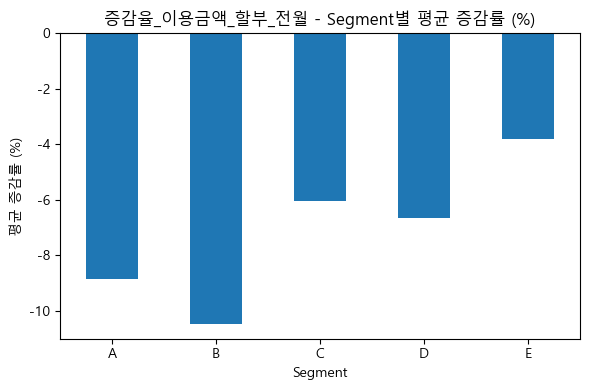

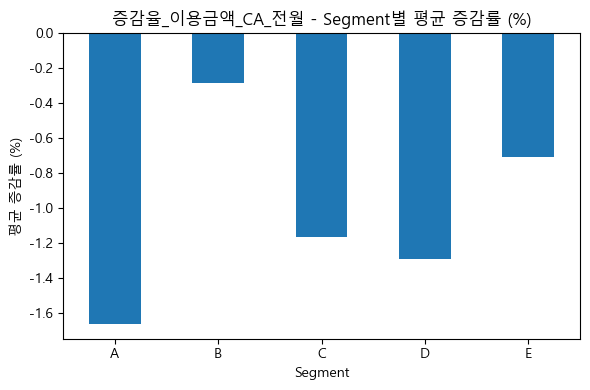

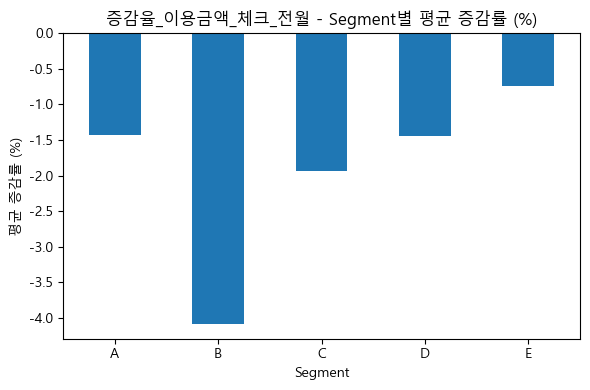

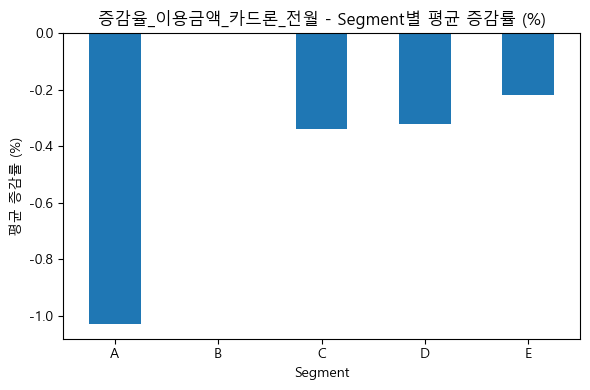

In [13]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[usage_amount_mom_cols].mean()

# 컬럼별 막대그래프 (퍼센트 변환 포함)
for col in usage_amount_mom_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')
    plt.title(f'{col} - Segment별 평균 증감률 (%)')
    plt.xlabel('Segment')
    plt.ylabel('평균 증감률 (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

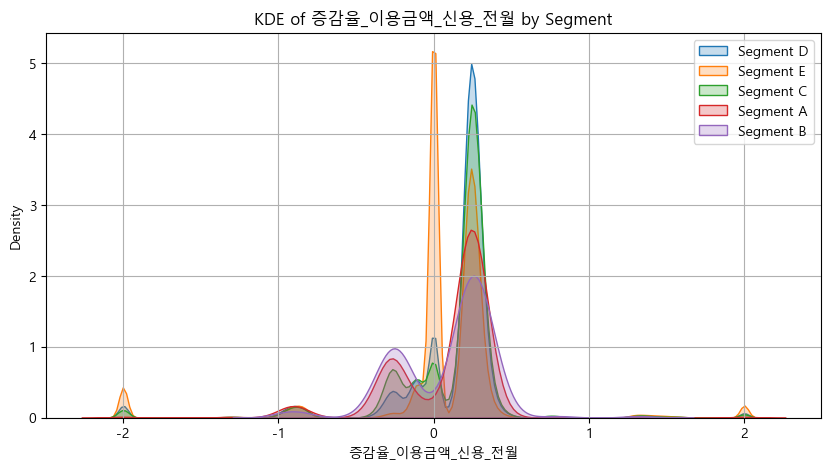

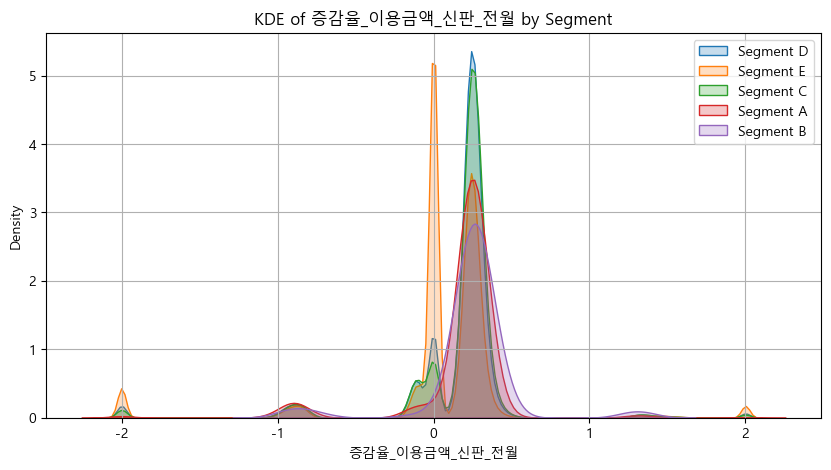

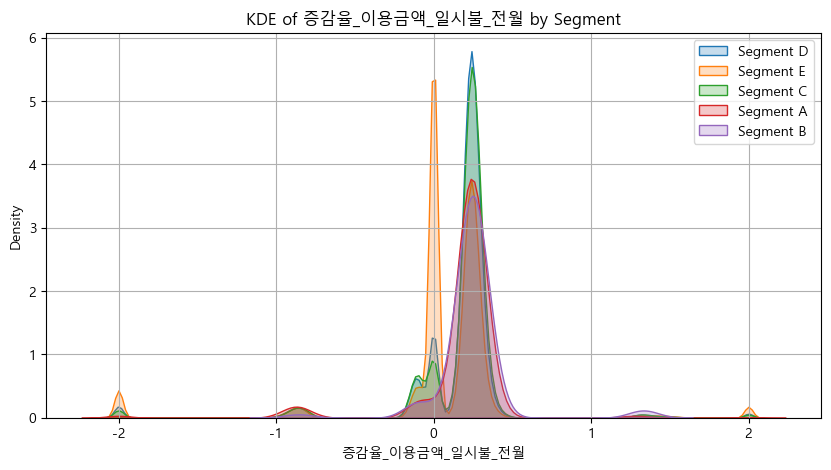

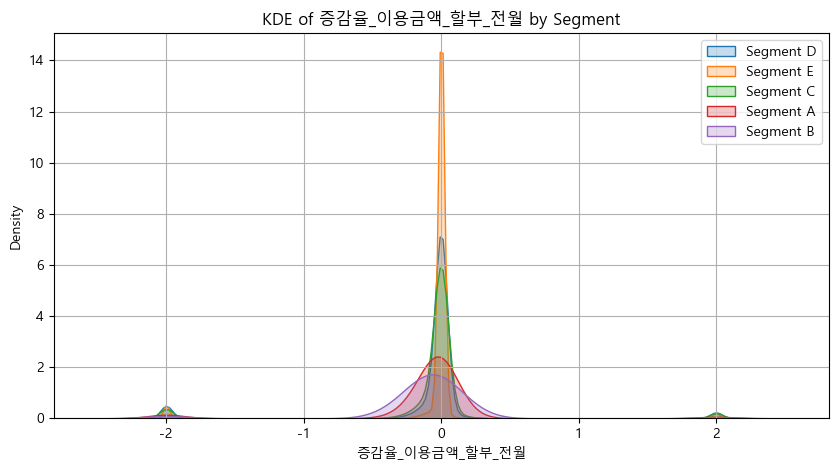

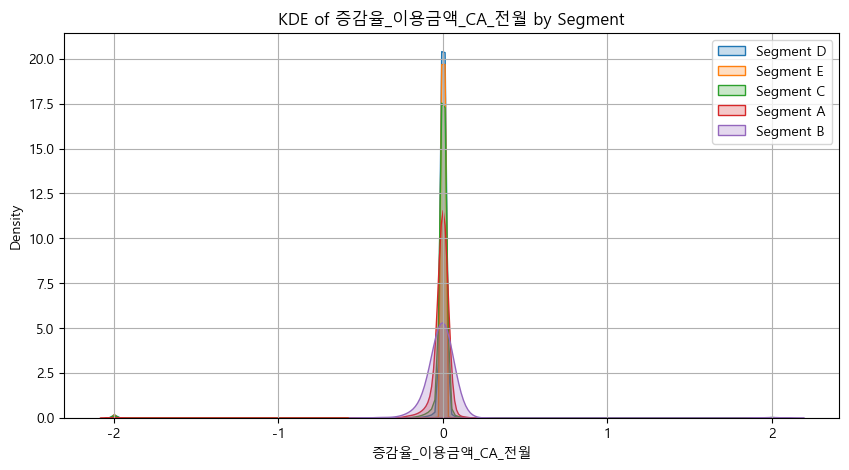

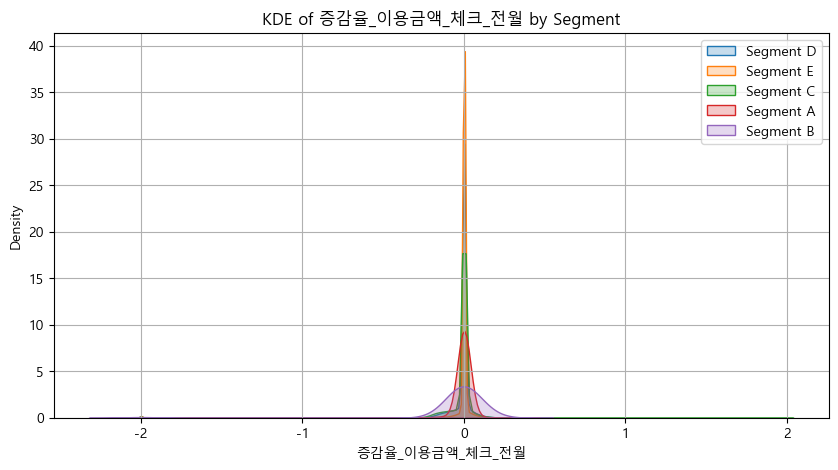

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\1770261439.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


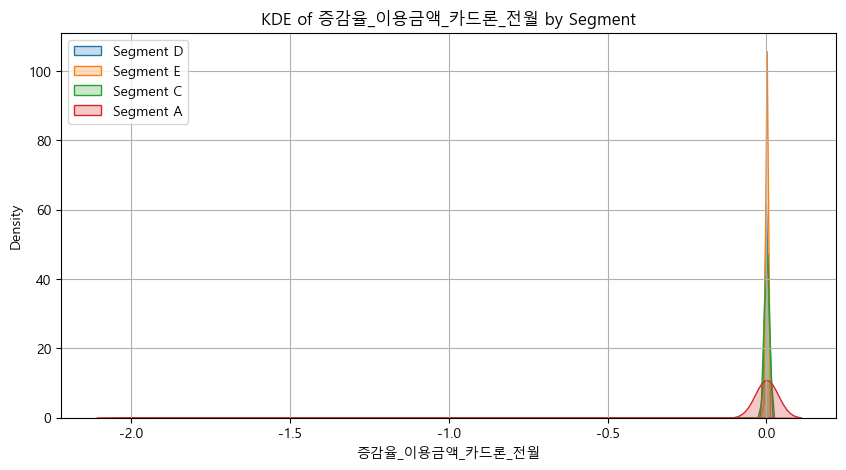

In [14]:
for col in usage_amount_mom_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## usage_count_qoq_cols

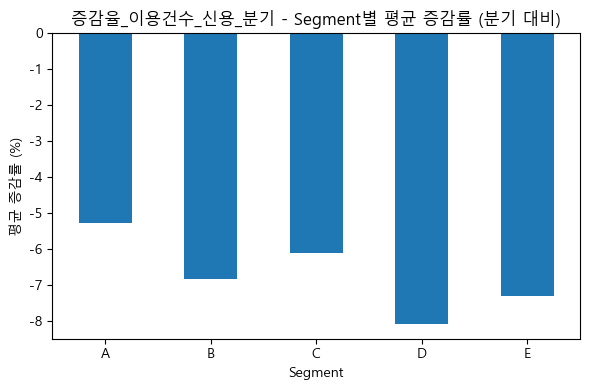

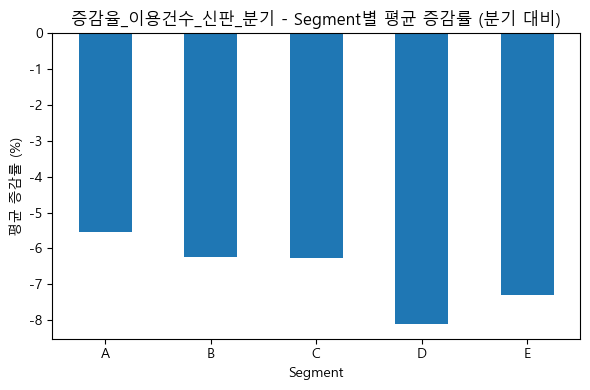

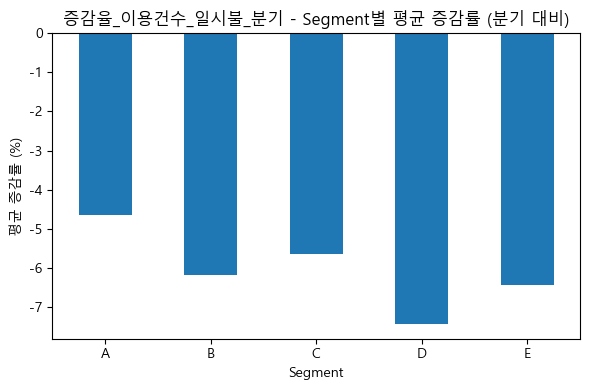

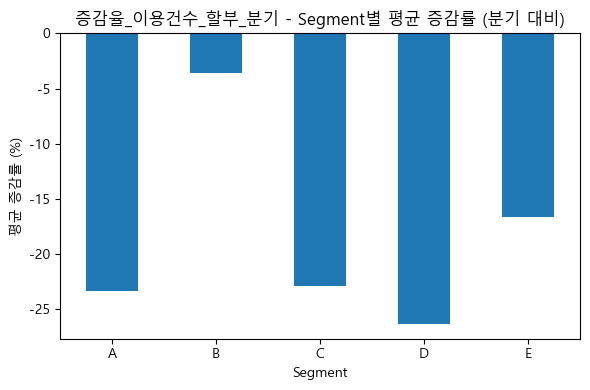

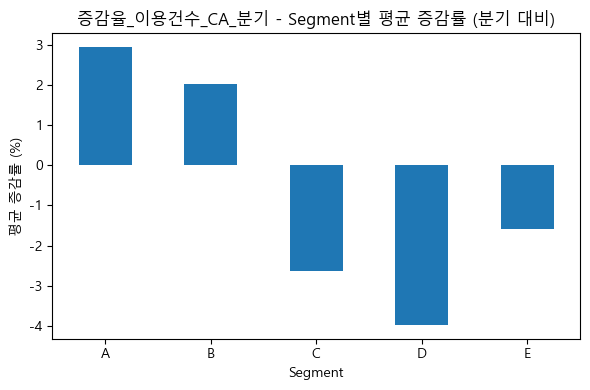

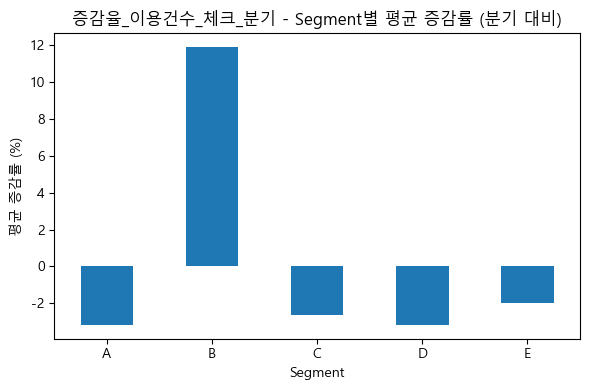

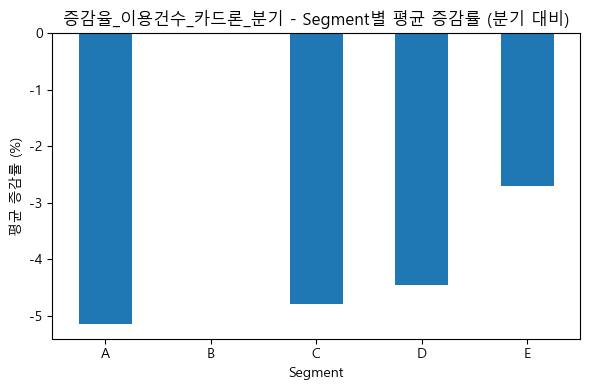

In [16]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[usage_count_qoq_cols].mean()

# 컬럼별 막대그래프 (퍼센트 변환 포함)
for col in usage_count_qoq_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')
    plt.title(f'{col} - Segment별 평균 증감률 (분기 대비)')
    plt.xlabel('Segment')
    plt.ylabel('평균 증감률 (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

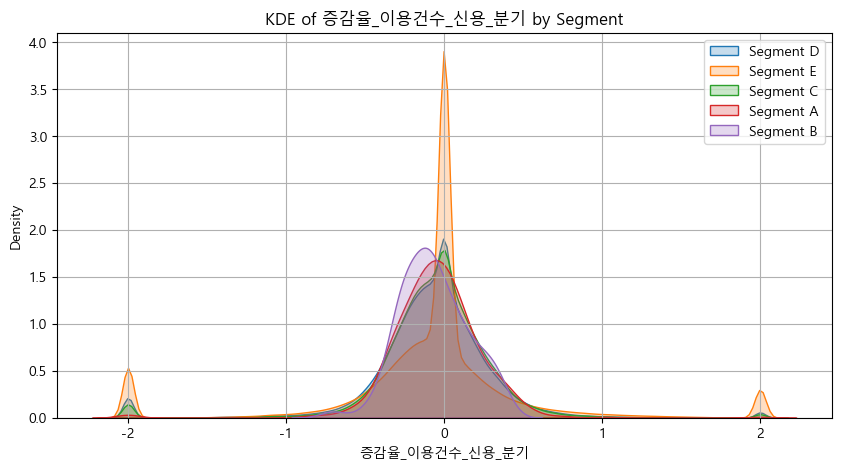

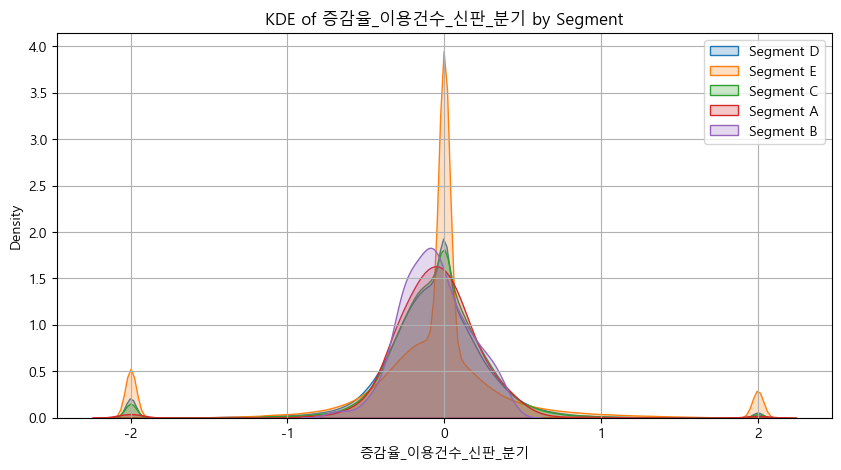

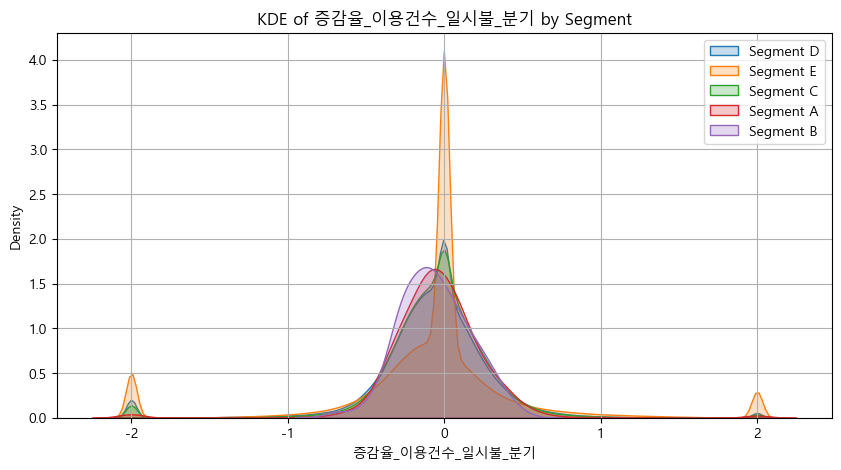

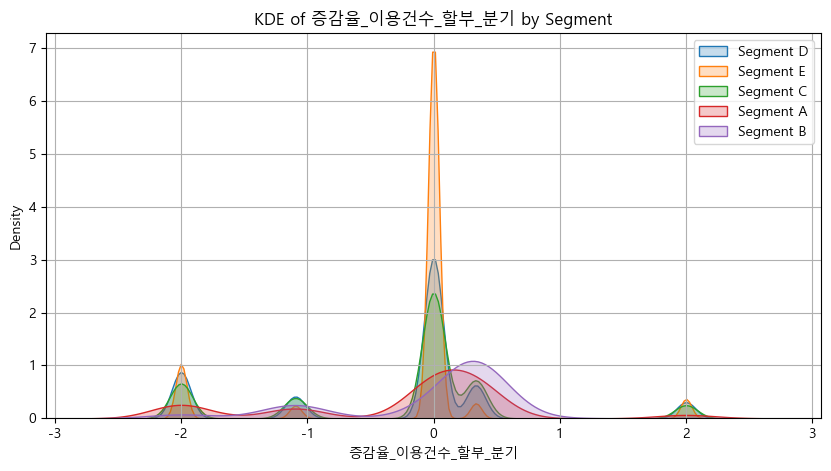

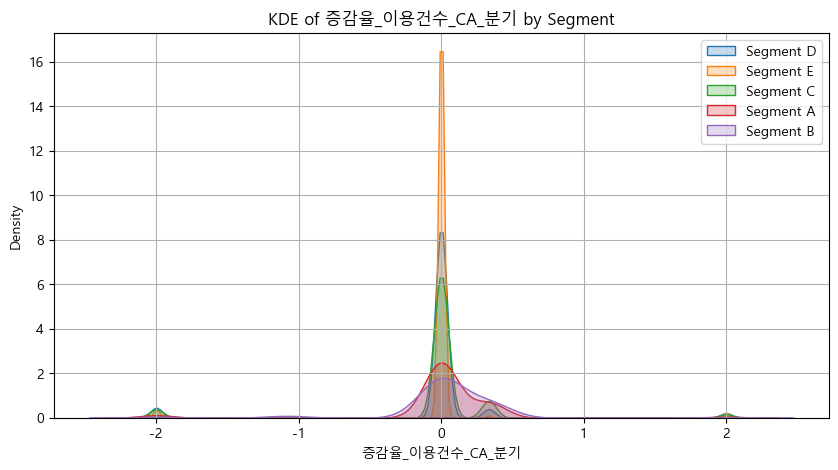

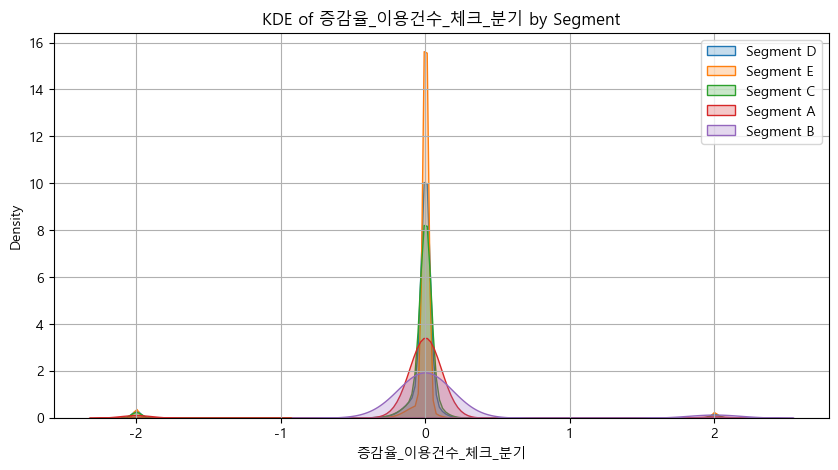

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\4267701238.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


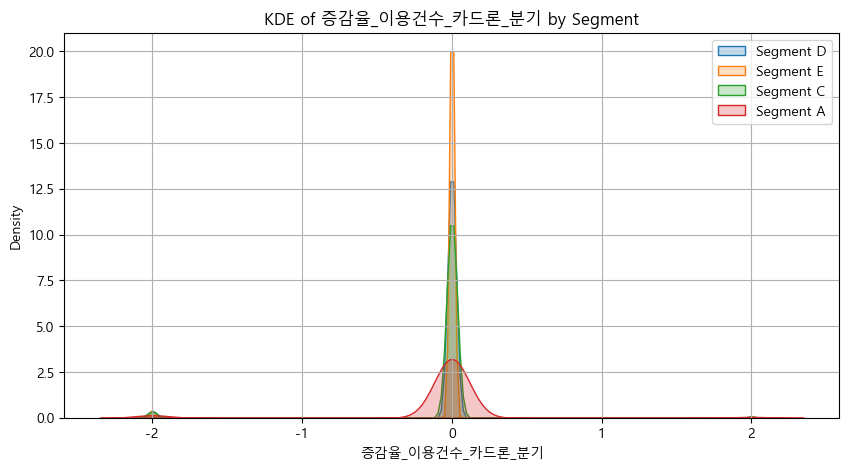

In [17]:
for col in usage_count_qoq_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## usage_amount_qoq_cols

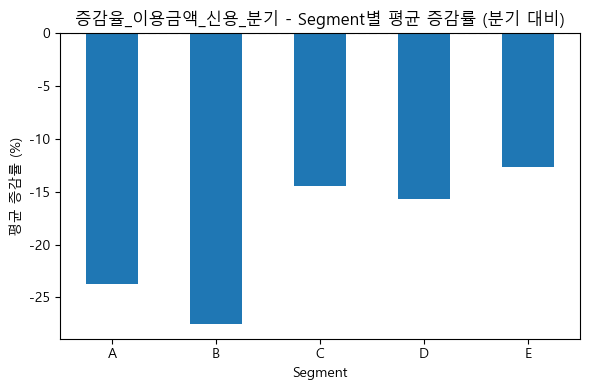

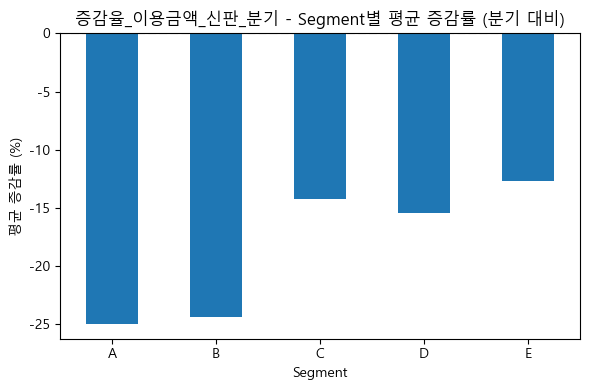

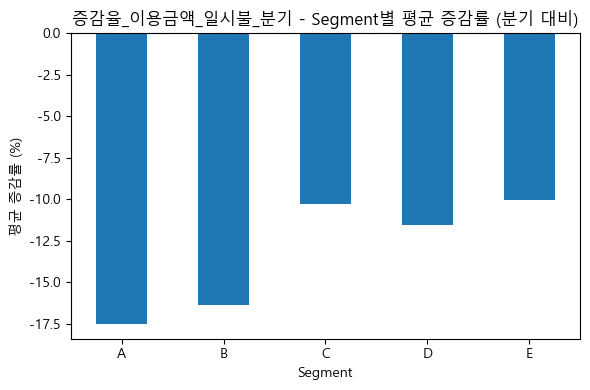

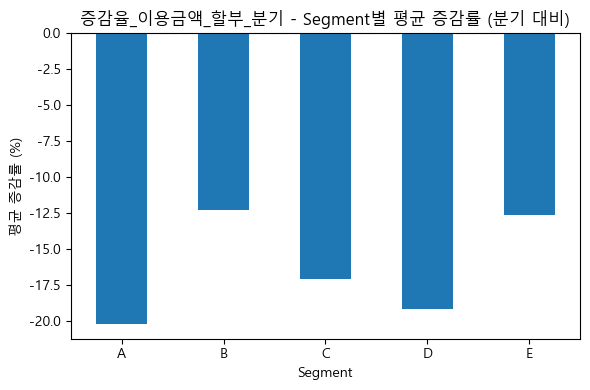

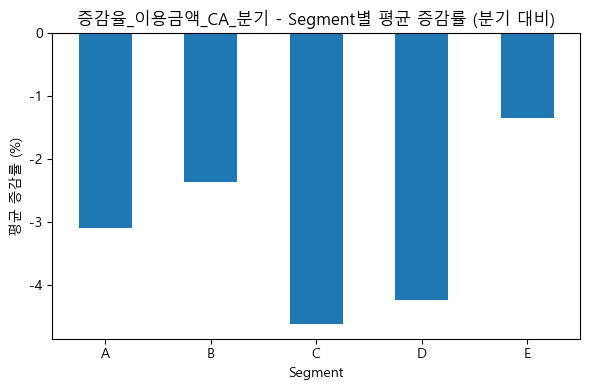

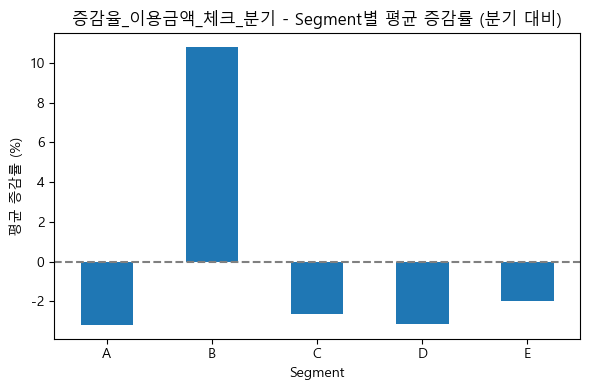

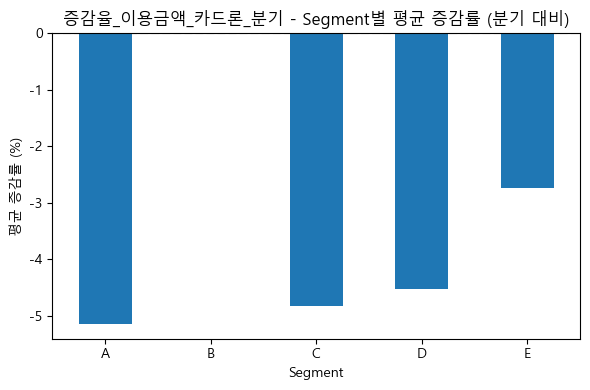

In [19]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[usage_amount_qoq_cols].mean()

# 컬럼별 막대그래프 (퍼센트 변환 포함)
for col in usage_amount_qoq_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')
    plt.title(f'{col} - Segment별 평균 증감률 (분기 대비)')
    plt.xlabel('Segment')
    plt.ylabel('평균 증감률 (%)')
    plt.axhline(0, color='gray', linestyle='--')  # 기준선 추가
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

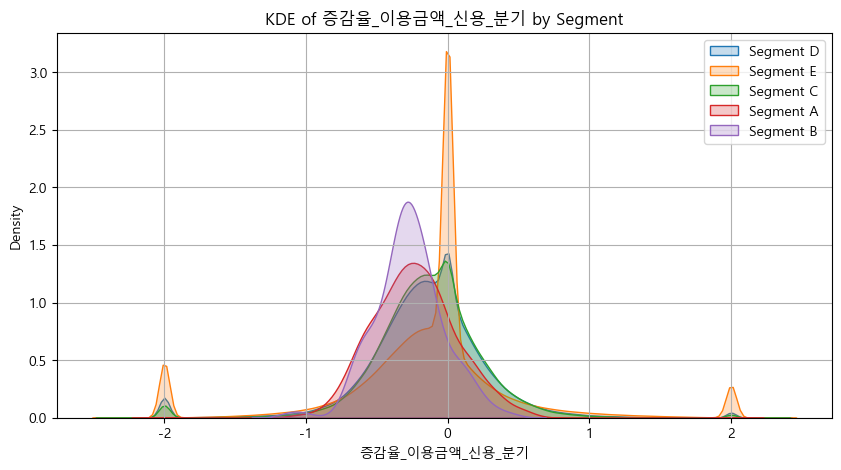

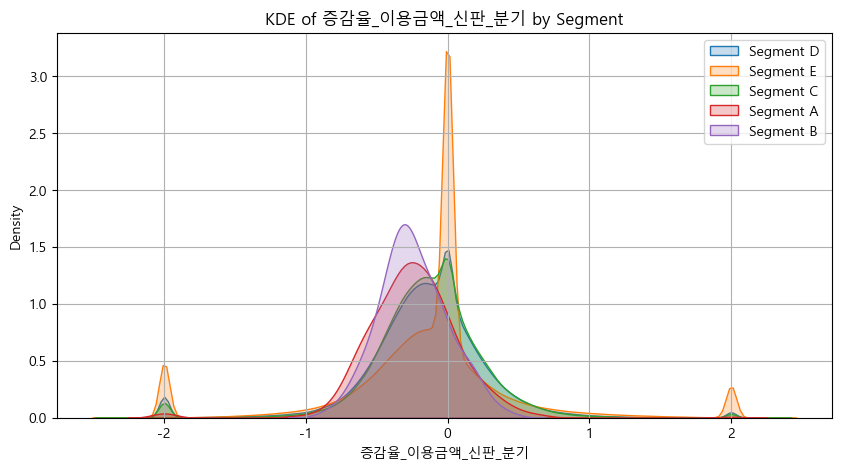

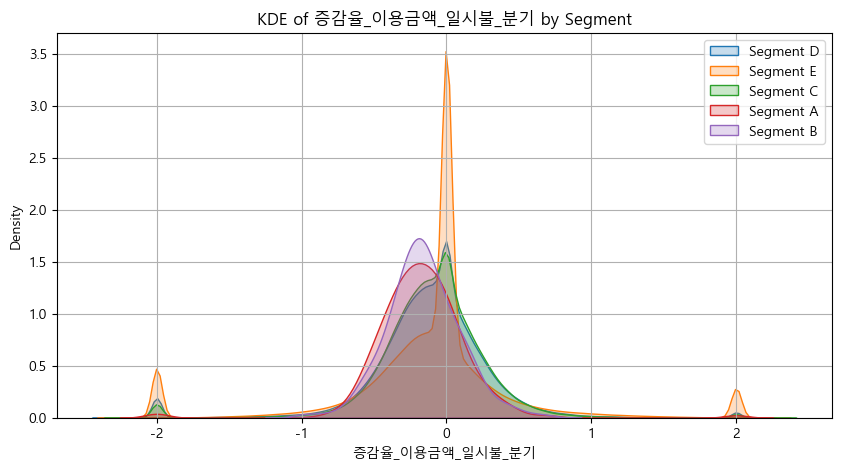

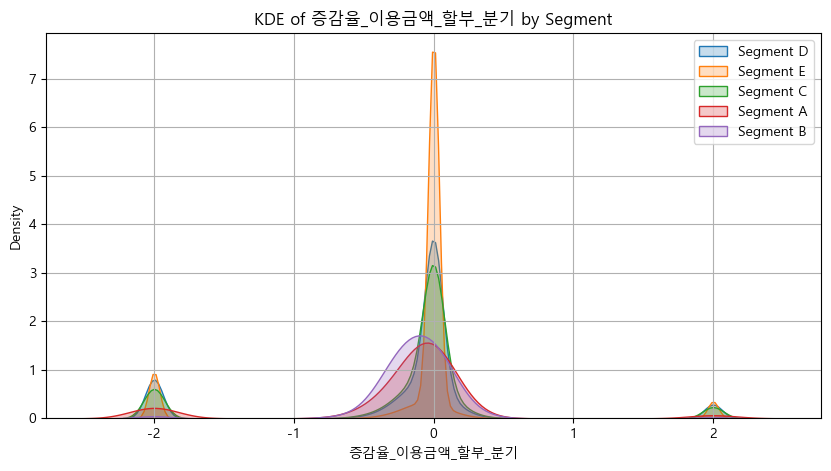

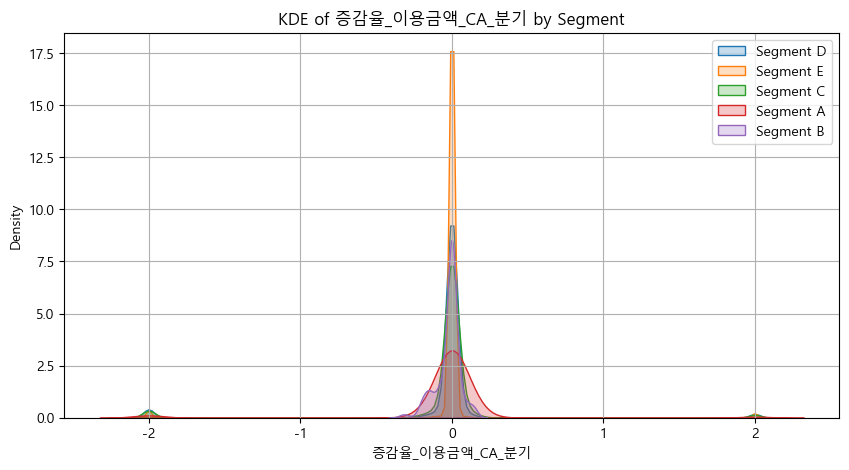

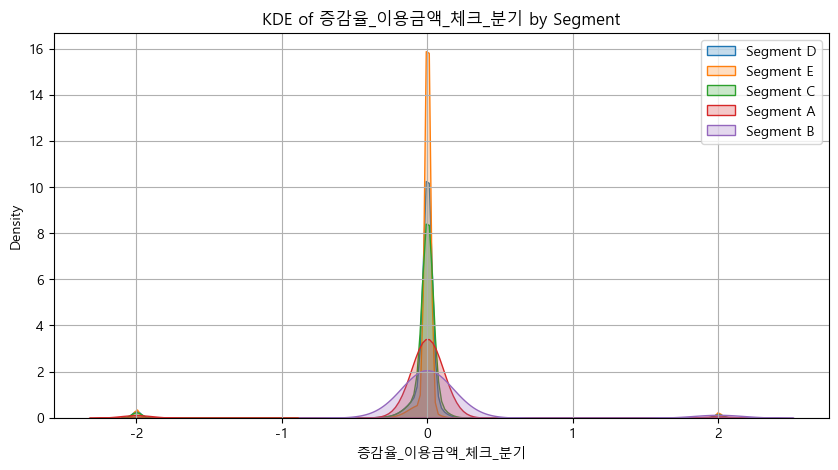

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\3643623161.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


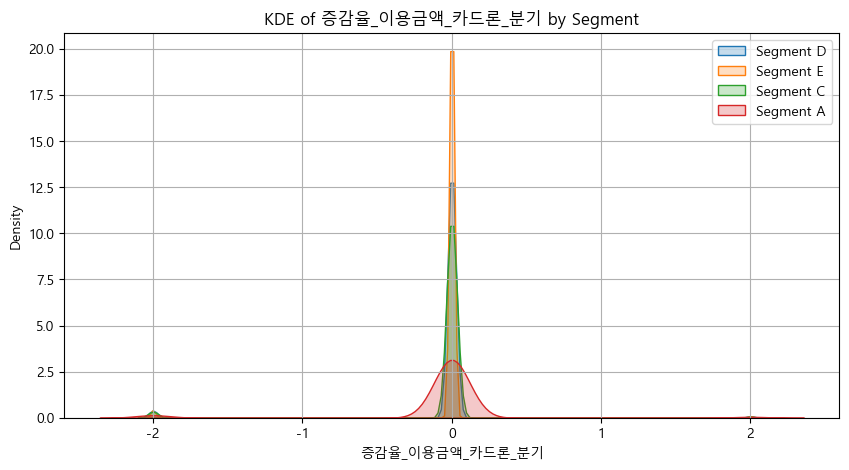

In [20]:
for col in usage_amount_qoq_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## limit_usage_credit_cols

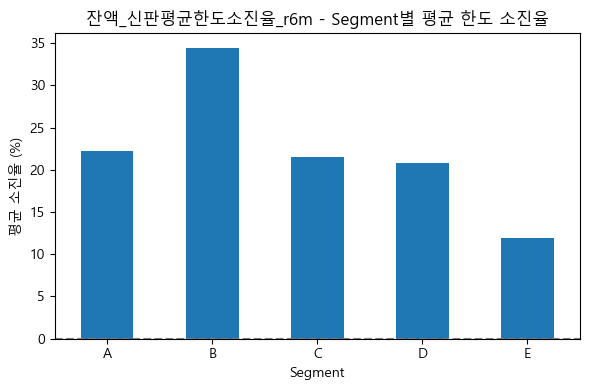

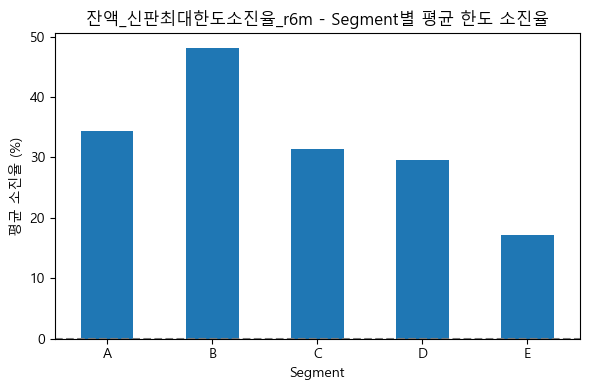

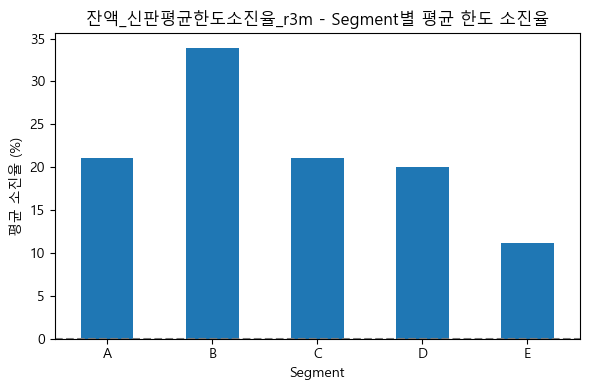

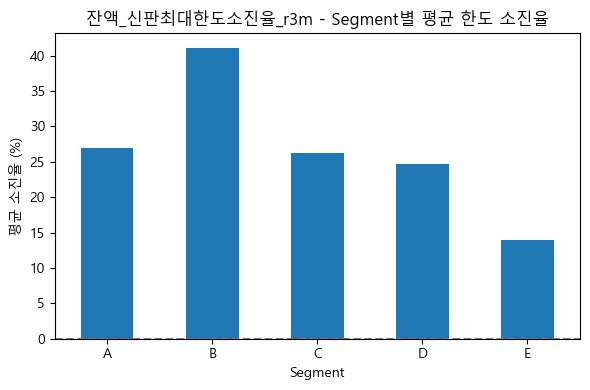

In [22]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[limit_usage_credit_cols].mean()

# 컬럼별 시각화
for col in limit_usage_credit_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')  # 퍼센트 단위로 변환
    plt.title(f'{col} - Segment별 평균 한도 소진율')
    plt.xlabel('Segment')
    plt.ylabel('평균 소진율 (%)')
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

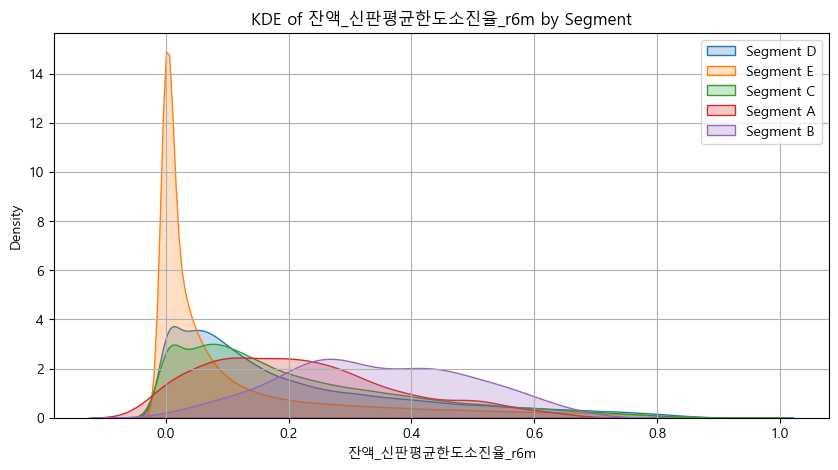

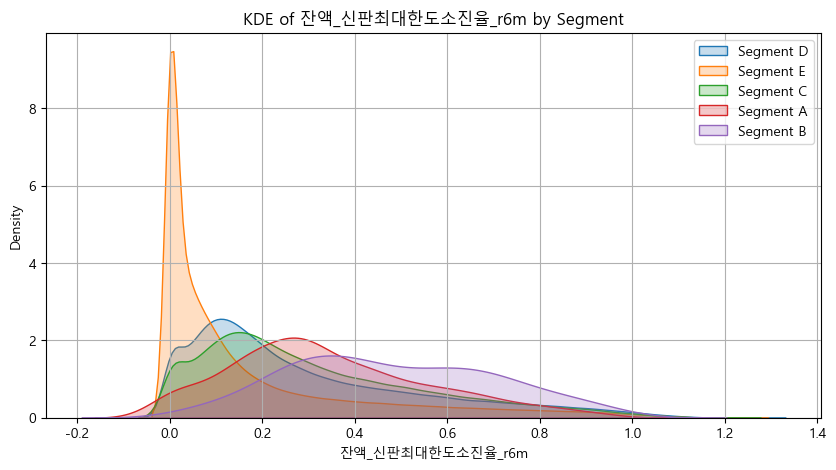

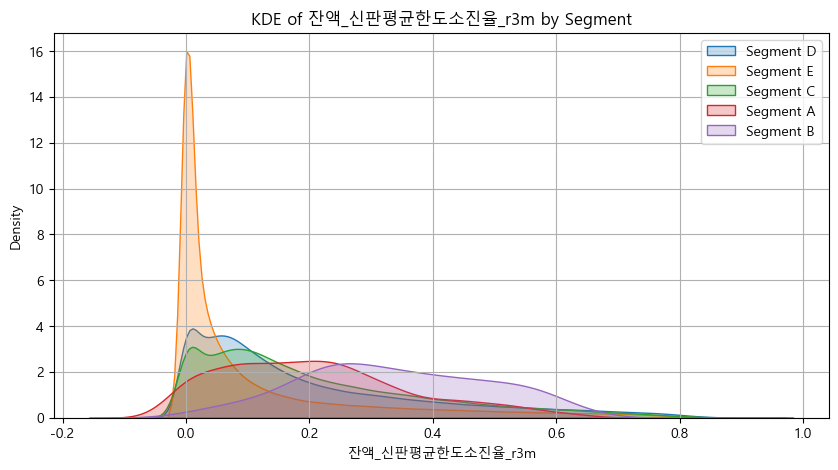

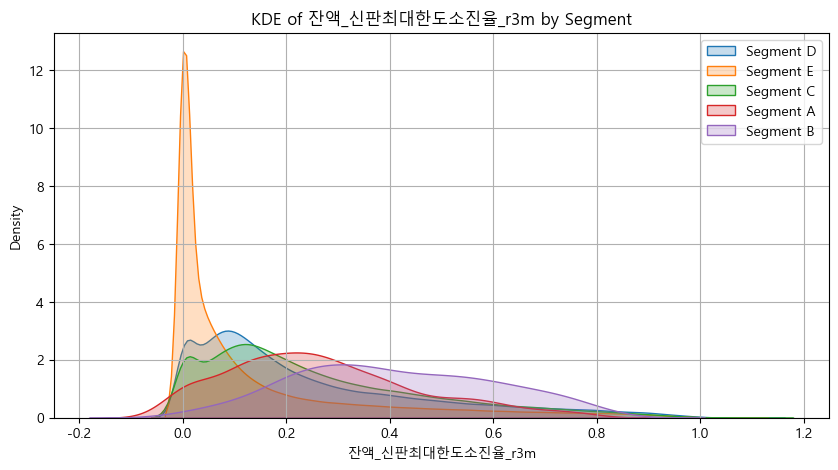

In [23]:
for col in limit_usage_credit_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## limit_usage_credit_ca_cols

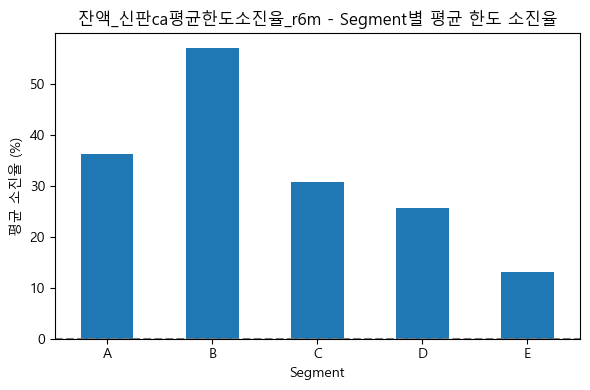

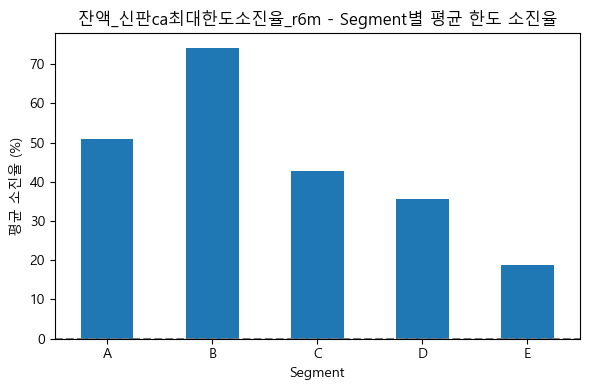

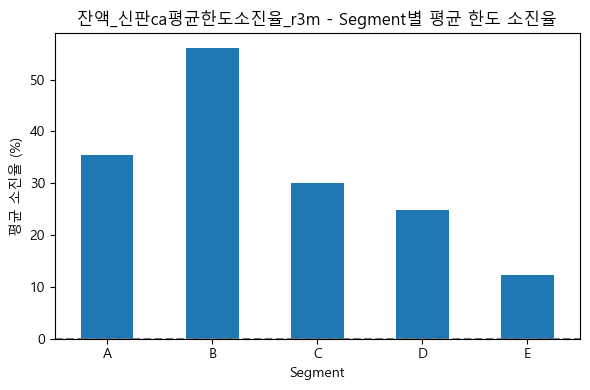

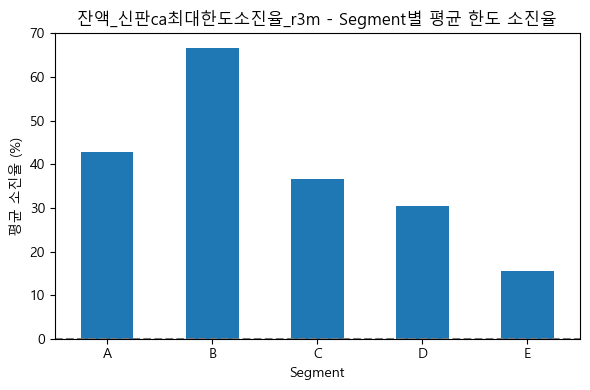

In [25]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[limit_usage_credit_ca_cols].mean()

# 컬럼별 시각화
for col in limit_usage_credit_ca_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')  # % 단위 변환
    plt.title(f'{col} - Segment별 평균 한도 소진율')
    plt.xlabel('Segment')
    plt.ylabel('평균 소진율 (%)')
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

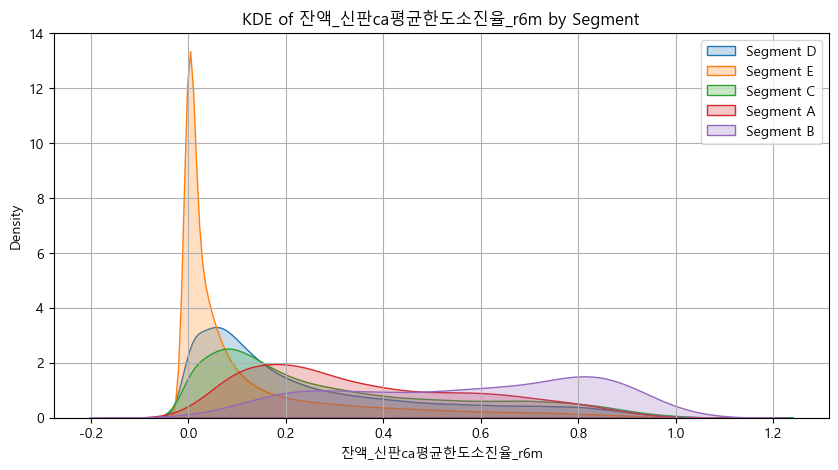

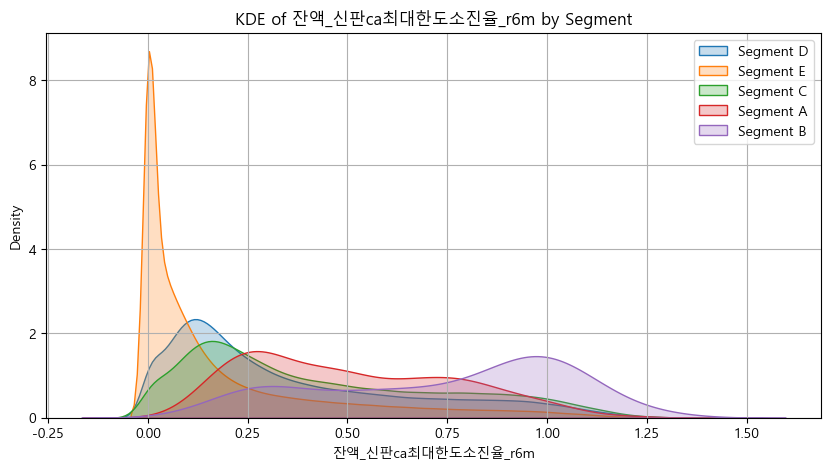

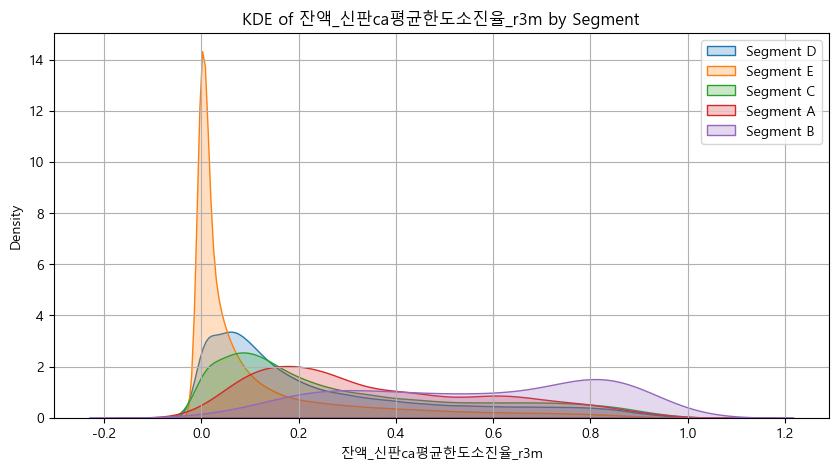

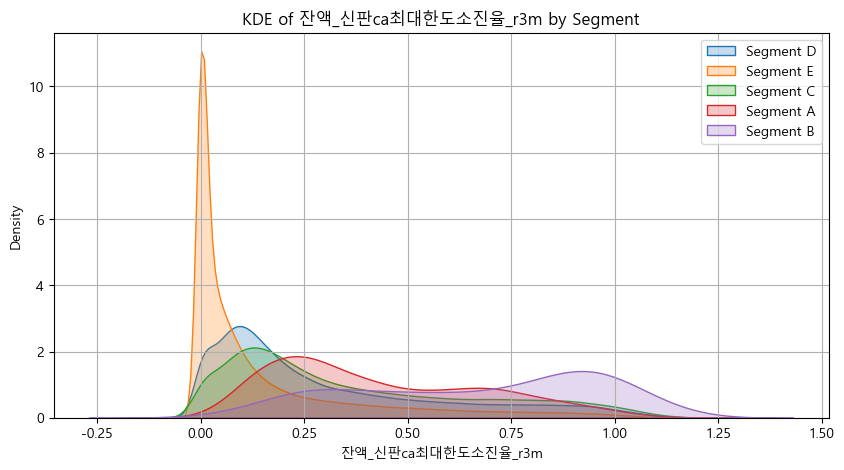

In [26]:
for col in limit_usage_credit_ca_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

## balance_change_cols

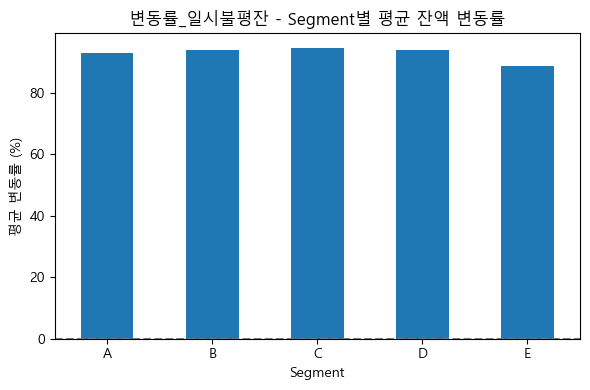

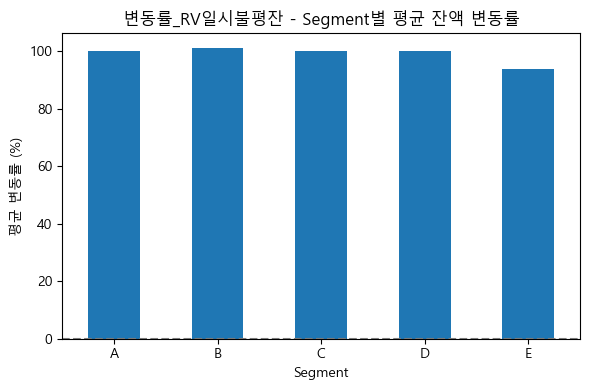

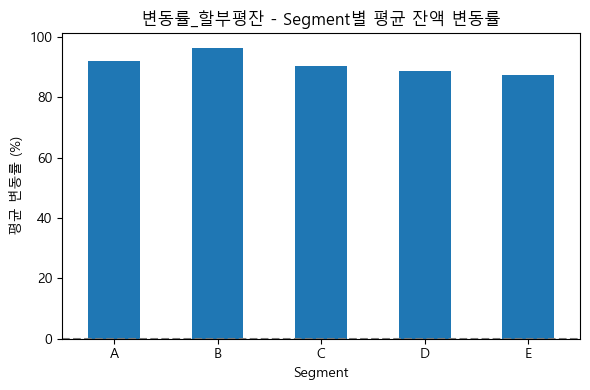

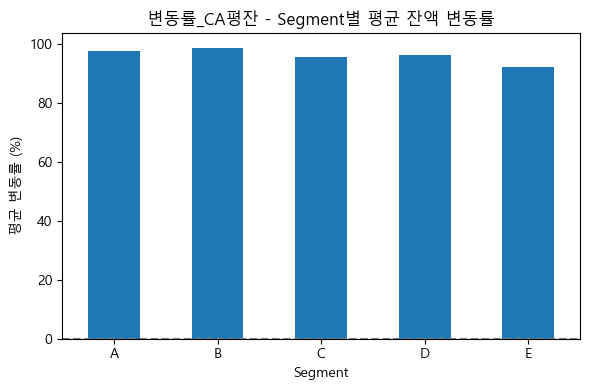

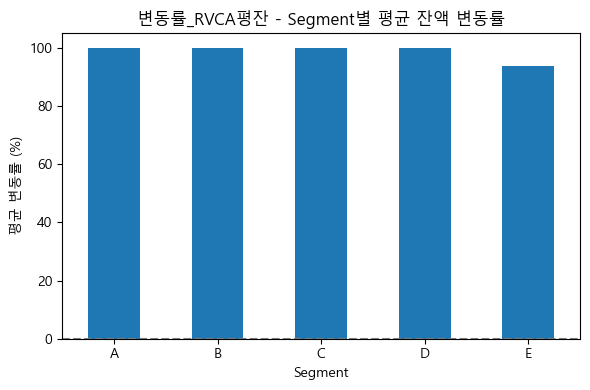

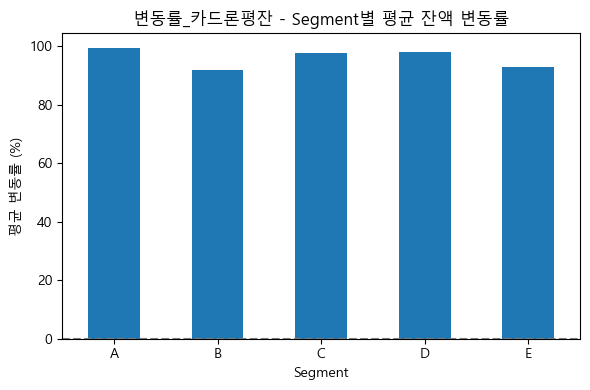

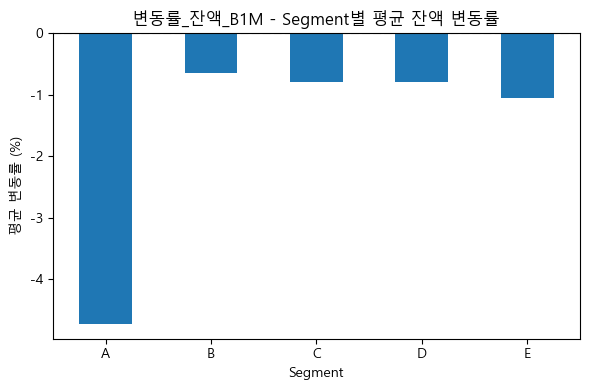

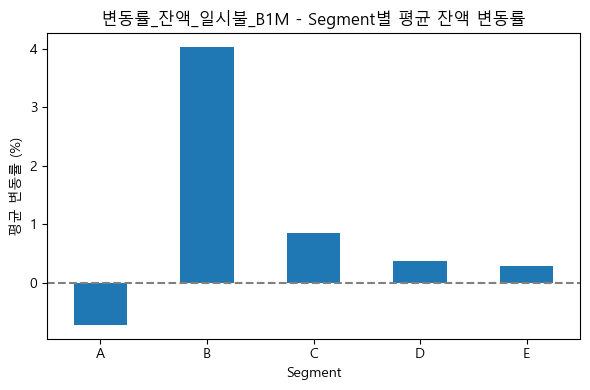

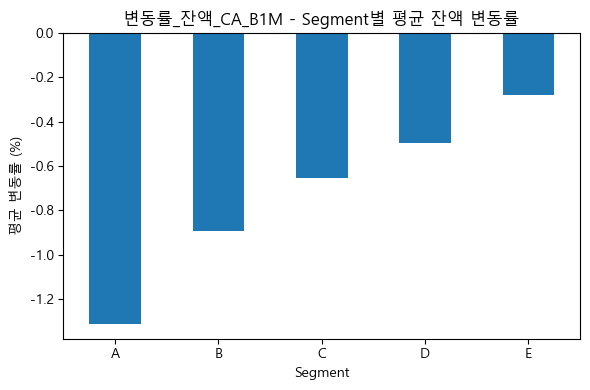

In [28]:
# Segment별 평균 계산
segment_grouped = merged_df.groupby('Segment')[balance_change_cols].mean()

# 컬럼별 시각화
for col in balance_change_cols:
    plt.figure(figsize=(6, 4))
    segment_grouped[col].mul(100).plot(kind='bar')  # 퍼센트 변환
    plt.title(f'{col} - Segment별 평균 잔액 변동률')
    plt.xlabel('Segment')
    plt.ylabel('평균 변동률 (%)')
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

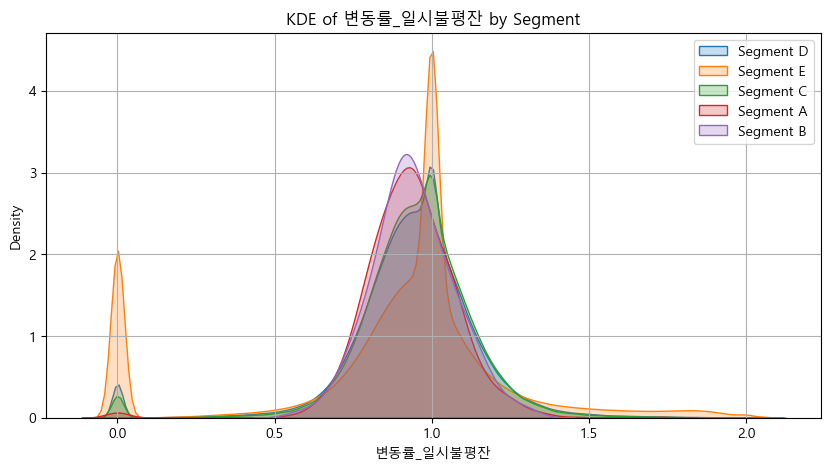

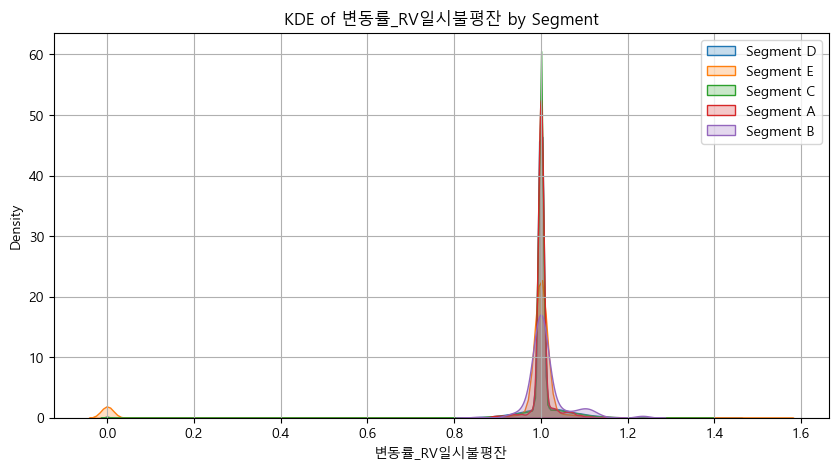

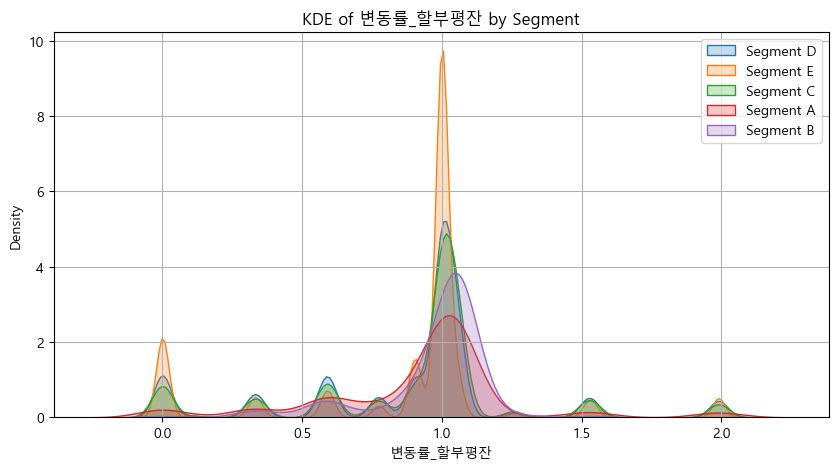

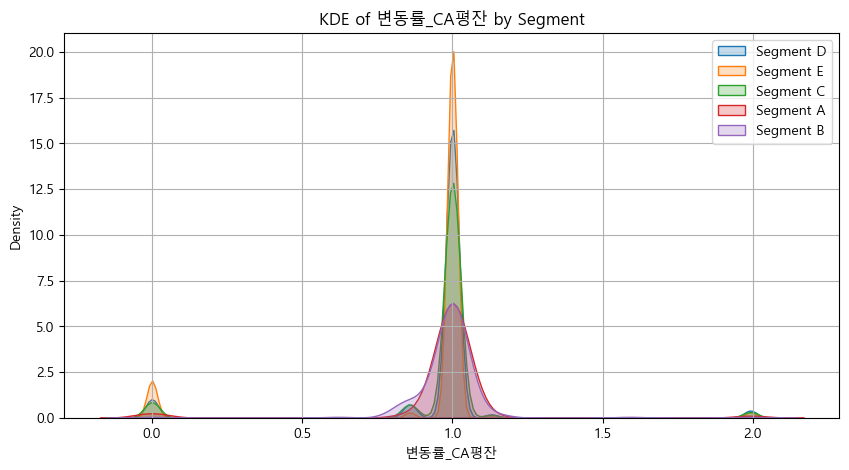

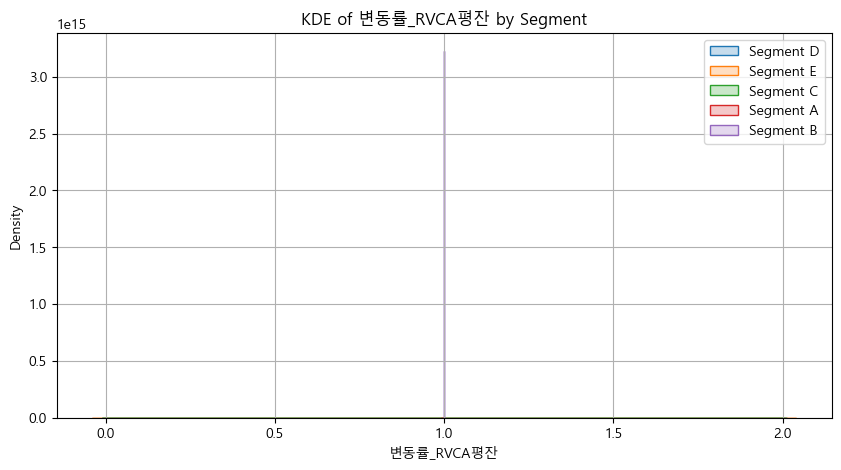

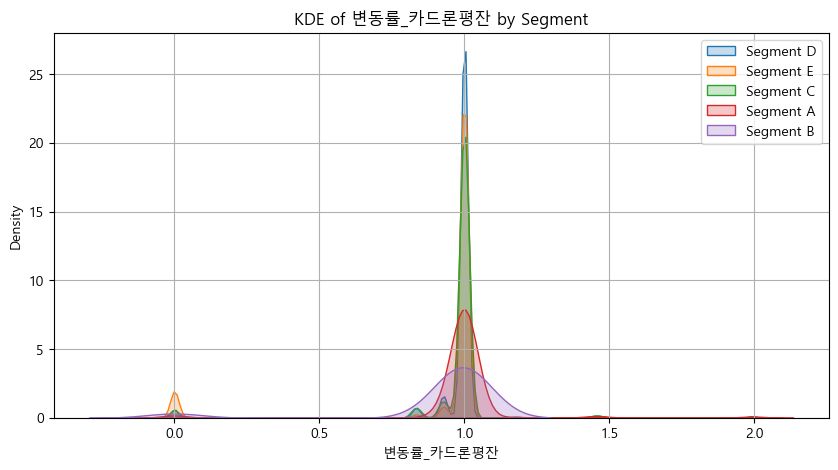

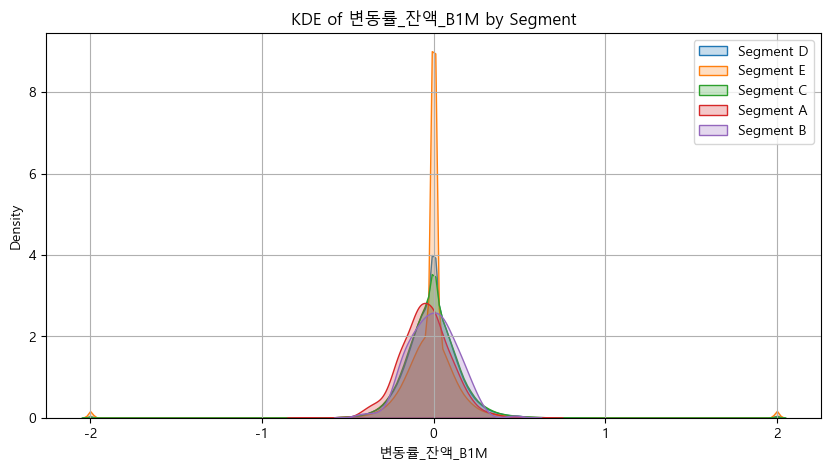

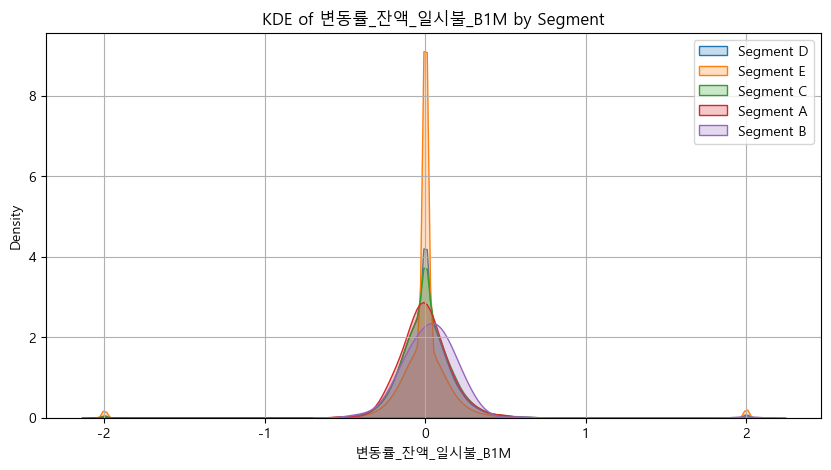

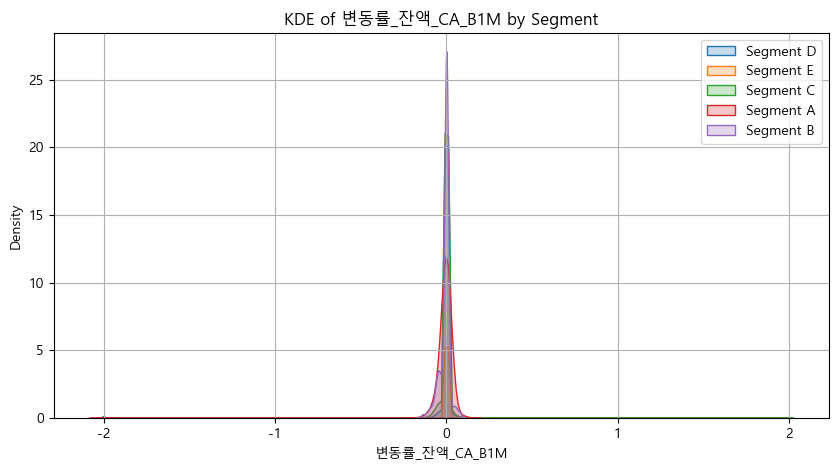

In [29]:
for col in balance_change_cols:
    plt.figure(figsize=(10, 5))
    for seg in merged_df['Segment'].unique():
        sns.kdeplot(
            data=merged_df[merged_df['Segment'] == seg].dropna(subset=[col]),
            x=col,
            label=f'Segment {seg}',
            fill=True,
            common_norm=False
        )
    plt.title(f'KDE of {col} by Segment')
    plt.legend()
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\372242512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


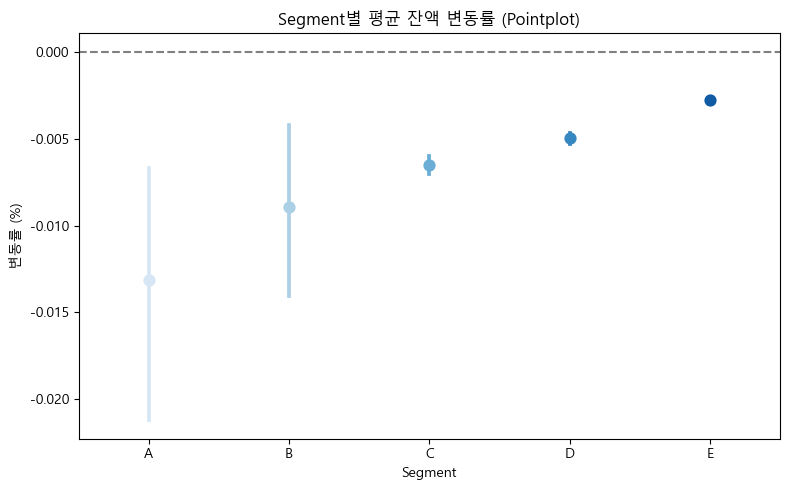

In [30]:
plt.figure(figsize=(8, 5))
sns.pointplot(
    data=merged_df,
    x='Segment',
    y='변동률_잔액_CA_B1M',
    order=['A', 'B', 'C', 'D', 'E'],
    palette='Blues'
)
plt.title('Segment별 평균 잔액 변동률 (Pointplot)')
plt.xlabel('Segment')
plt.ylabel('변동률 (%)')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


## 수치로 확인

In [32]:
from scipy.stats import f_oneway
import numpy as np

cols = [
    '잔액_신판ca최대한도소진율_r6m',  # D vs E
    '잔액_신판최대한도소진율_r6m',     # D vs C/E
    '잔액_신판ca평균한도소진율_r6m',  # D vs E
    '증감율_이용건수_할부_전월'         # D vs C
]

cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])]

for col in cols:
    c = cde_df[cde_df['Segment'] == 'C'][col].dropna()
    d = cde_df[cde_df['Segment'] == 'D'][col].dropna()
    e = cde_df[cde_df['Segment'] == 'E'][col].dropna()
    
    # ANOVA
    f_stat, p_val = f_oneway(c, d, e)
    
    # 평균
    mean_c, mean_d, mean_e = c.mean(), d.mean(), e.mean()
    
    # 표준편차
    std_c, std_d, std_e = c.std(), d.std(), e.std()
    
    # Cohen's d
    pooled_std_dc = np.sqrt((std_d ** 2 + std_c ** 2) / 2)
    pooled_std_de = np.sqrt((std_d ** 2 + std_e ** 2) / 2)
    cohen_d_dc = (d.mean() - c.mean()) / pooled_std_dc
    cohen_d_de = (d.mean() - e.mean()) / pooled_std_de

    print(f"\n📌 Feature: {col}")
    print(f"F-statistic: {f_stat:.2f}, p-value: {p_val:.5f}")
    print(f"Means - C: {mean_c:.2f}, D: {mean_d:.2f}, E: {mean_e:.2f}")
    print(f"StdDevs - C: {std_c:.2f}, D: {std_d:.2f}, E: {std_e:.2f}")
    print(f"Cohen's d (D vs C): {cohen_d_dc:.2f}, (D vs E): {cohen_d_de:.2f}")



📌 Feature: 잔액_신판ca최대한도소진율_r6m
F-statistic: 96593.40, p-value: 0.00000
Means - C: 0.43, D: 0.36, E: 0.19
StdDevs - C: 0.31, D: 0.30, E: 0.26
Cohen's d (D vs C): -0.23, (D vs E): 0.60

📌 Feature: 잔액_신판최대한도소진율_r6m
F-statistic: 55245.04, p-value: 0.00000
Means - C: 0.31, D: 0.30, E: 0.17
StdDevs - C: 0.24, D: 0.25, E: 0.24
Cohen's d (D vs C): -0.07, (D vs E): 0.51

📌 Feature: 잔액_신판ca평균한도소진율_r6m
F-statistic: 84778.16, p-value: 0.00000
Means - C: 0.31, D: 0.26, E: 0.13
StdDevs - C: 0.26, D: 0.25, E: 0.20
Cohen's d (D vs C): -0.20, (D vs E): 0.56

📌 Feature: 증감율_이용건수_할부_전월
F-statistic: 8323.19, p-value: 0.00000
Means - C: -0.19, D: -0.17, E: -0.07
StdDevs - C: 0.70, D: 0.68, E: 0.46
Cohen's d (D vs C): 0.03, (D vs E): -0.17


In [33]:
cols = [
    '잔액_신판ca최대한도소진율_r6m',  
    '잔액_신판최대한도소진율_r6m',     
    '잔액_신판ca평균한도소진율_r6m',  
    '증감율_이용건수_할부_전월'
]
segment_targets = ['C', 'D', 'E']
cv_results = {}

for col in cols:
    cv_results[col] = {}
    for seg in segment_targets:
        seg_data = merged_df[merged_df['Segment'] == seg][col].dropna()
        mean = seg_data.mean()
        std = seg_data.std()
        cv = std / mean if mean != 0 else float('inf')
        cv_results[col][seg] = round(cv, 3)

# 결과를 DataFrame으로 보기 좋게 출력
import pandas as pd
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ['CV_C', 'CV_D', 'CV_E']
cv_df['CV_Diff_D_vs_CE'] = cv_df['CV_D'] - ((cv_df['CV_C'] + cv_df['CV_E']) / 2)
cv_df

,CV_C,CV_D,CV_E,CV_Diff_D_vs_CE
잔액_신판ca최대한도소진율_r6m,0.733,0.849,1.390,-0.2125
잔액_신판최대한도소진율_r6m,0.769,0.855,1.394,-0.2265
잔액_신판ca평균한도소진율_r6m,0.842,0.969,1.545,-0.2245
증감율_이용건수_할부_전월,-3.755,-4.110,-6.990,1.2625


C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\3805926855.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


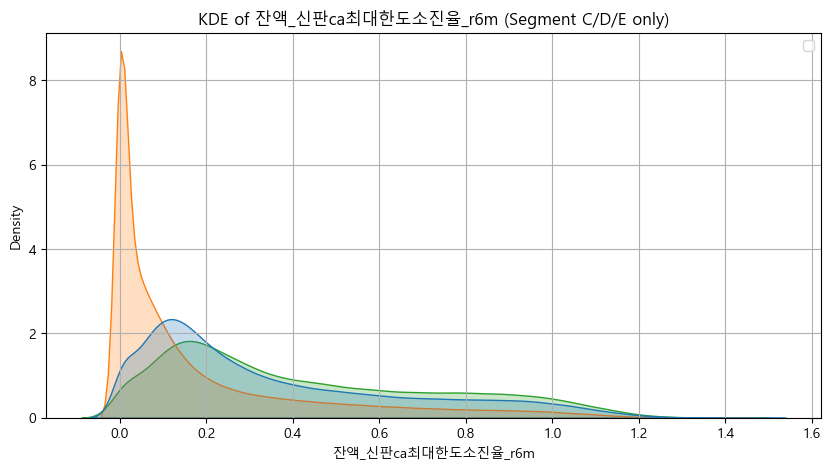

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\3805926855.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


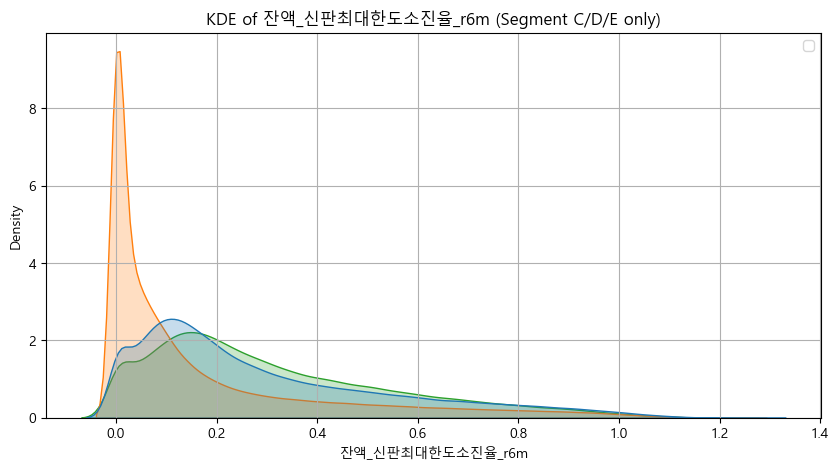

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\3805926855.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


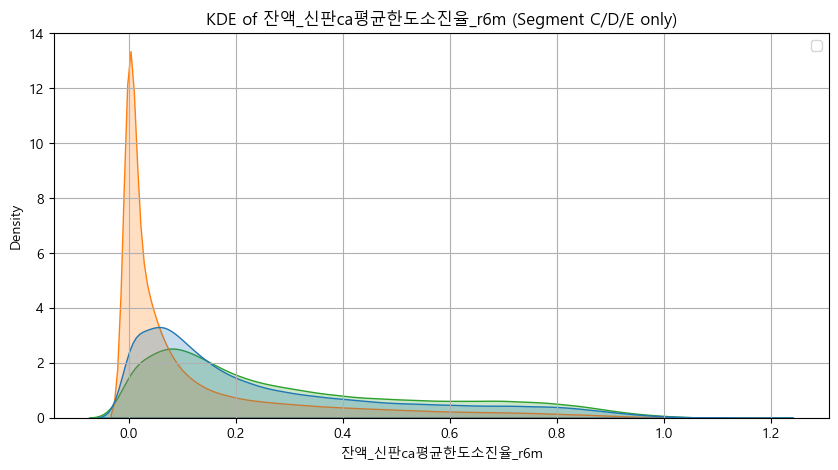

C:\Users\xodlf\AppData\Local\Temp\ipykernel_12556\3805926855.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


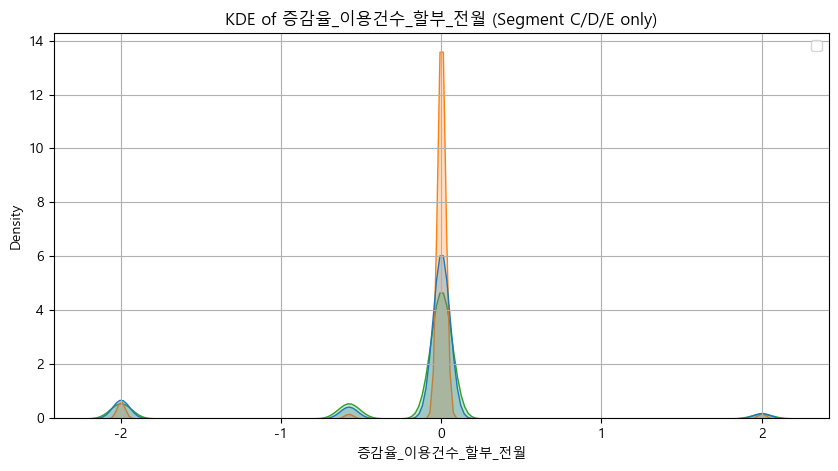

In [34]:
cols = [
    '잔액_신판ca최대한도소진율_r6m',  
    '잔액_신판최대한도소진율_r6m',     
    '잔액_신판ca평균한도소진율_r6m',  
    '증감율_이용건수_할부_전월'
]
# Segment C, D, E만 필터링
cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])]

for col in cols:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(
        data=cde_df,
        x=col,
        hue='Segment',
        fill=True,
        common_norm=False
    )
    plt.title(f'KDE of {col} (Segment C/D/E only)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.legend()
    plt.show()

In [65]:
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')


# Segment C/D/E만 사용
cde_df = merged_df[merged_df['Segment'].isin(['C', 'D', 'E'])].copy()
# cde_df = merged_df[merged_df['Segment'].isin(['A','B','C', 'D', 'E'])].copy()

# 수치형 컬럼 자동 추출
numeric_cols = cde_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'ID']  # ID 등 제외

# 결과 저장
results = []

for col in numeric_cols:
    try:
        # binning (5등분, quantile 기반)
        discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
        binned = discretizer.fit_transform(cde_df[[col]])
        cde_df['binned'] = binned

        # 교차표 생성
        contingency = pd.crosstab(cde_df['binned'], cde_df['Segment'])

        # 카이제곱 검정
        chi2, p, dof, expected = chi2_contingency(contingency)

        results.append({
            'Feature': col,
            'Chi2 Stat': chi2,
            'p-value': round(p, 10),
        })
    except:
        continue  # NaN 또는 에러나는 컬럼은 건너뜀

# 상위 10개 정렬 및 출력
result_df = pd.DataFrame(results)
top10 = result_df.sort_values(by='Chi2 Stat', ascending=False).head(10)
top10[['Feature', 'Chi2 Stat', 'p-value']]

,Feature,Chi2 Stat,p-value
34,잔액_신판ca최대한도소진율_r6m,255521.211577,0.0
36,잔액_신판ca최대한도소진율_r3m,253807.357826,0.0
35,잔액_신판ca평균한도소진율_r3m,240707.103278,0.0
33,잔액_신판ca평균한도소진율_r6m,233737.953464,0.0
32,잔액_신판최대한도소진율_r3m,219073.927928,0.0
30,잔액_신판최대한도소진율_r6m,218590.592014,0.0
31,잔액_신판평균한도소진율_r3m,205903.734660,0.0
29,잔액_신판평균한도소진율_r6m,196774.228195,0.0
9,증감율_이용금액_신판_전월,132821.074064,0.0
10,증감율_이용금액_일시불_전월,129447.034415,0.0
